### ***5ARE0 Data Analysis and Learning Methods***

## ***Human Activity Recognition for Healthy Lifestyle Monitoring***

***Group Members: Liya Boro, Özde Pilli, Yusuf Berkan Gökçe***

This project focuses on building a machine learning pipeline to classify five basic human activities: sitting down, standing up, walking, running, and climbing stairs—using smartphone sensor data (accelerometer, gyroscope, gravity).  

**Background and Relevance :**
Human Activity Recognition (HAR) using wearable sensors plays a key role in modern health monitoring, as seen in fitness trackers and smartwatches. Reliable detection of daily activities can support healthy lifestyle interventions, especially for elderly populations. This assignment focuses on five core activities, sitting down, standing up, walking, running, and climbing stairs, to explore how sensor-based data can be transformed into actionable insights for wellness and digital health applications.

**Aim and Research Questions :**
The goal is to develop and evaluate machine learning models that classify these activities using smartphone sensor data to support healthy lifestyle monitoring.

Key questions to address:
1. Which sensor-derived features best distinguish the five target activities?
2. How do supervised vs. unsupervised learning approaches compare for this classification task?
3. Which model achieves the highest accuracy and reliability when combined with appropriate feature extraction and selection?
4. What are the practical considerations and limitations for deploying such systems in real-world health monitoring contexts?


***Below are the helper functions required for this notebook. Run all these cells first, then continue with the assignment results.***

In [2]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
# ----- create_csv.py -----

from scipy.stats import skew, kurtosis, entropy

# ---------- Feature helpers ----------
def _time_features(sig: np.ndarray) -> dict:
    if sig.size == 0:
        return {k: np.nan for k in ["mean","std","min","max","median","iqr","rms","skew","kurtosis"]}
    return {
        "mean": float(np.mean(sig)),
        "std": float(np.std(sig, ddof=1)) if sig.size > 1 else 0.0,
        "min": float(np.min(sig)),
        "max": float(np.max(sig)),
        "median": float(np.median(sig)),
        "iqr": float(np.subtract(*np.percentile(sig, [75, 25]))),
        "rms": float(np.sqrt(np.mean(sig**2))),
        "skew": float(skew(sig, bias=False)) if sig.size > 2 else 0.0,
        "kurtosis": float(kurtosis(sig, fisher=True, bias=False)) if sig.size > 3 else 0.0,
    }

def _spectral_features(sig: np.ndarray, fs: float) -> dict:
    if sig.size == 0 or not np.isfinite(fs) or fs <= 0:
        return {"dom_freq": np.nan, "spec_entropy": np.nan, "spec_energy": np.nan, "spec_centroid": np.nan}
    x = sig - np.mean(sig)
    n = x.size
    if n < 2:
        return {"dom_freq": np.nan, "spec_entropy": np.nan, "spec_energy": np.nan, "spec_centroid": np.nan}
    # Hann window to reduce leakage
    hann = 0.5 - 0.5*np.cos(2*np.pi*np.arange(n)/n)
    xw = x * hann
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    spec = np.abs(np.fft.rfft(xw))**2
    if spec.sum() <= 0:
        return {"dom_freq": 0.0, "spec_entropy": 0.0, "spec_energy": 0.0, "spec_centroid": 0.0}

    # Dominant frequency (prefer non-DC)
    spec_no_dc = spec.copy()
    if spec_no_dc.size > 1:
        spec_no_dc[0] = 0.0
    dom_idx = int(np.argmax(spec_no_dc)) if spec_no_dc.sum() > 0 else int(np.argmax(spec))
    dom_freq = float(freqs[dom_idx])

    p = spec / spec.sum()
    return {
        "dom_freq": dom_freq,
        "spec_entropy": float(entropy(p)),              # natural log base
        "spec_energy": float(spec.sum() / n),          # average spectral energy
        "spec_centroid": float((freqs * spec).sum() / spec.sum()),
    }

def _per_axis_and_mag_features(df_sensor: pd.DataFrame, fs: float, prefix: str) -> dict:
    """
    Computes (for x,y,z,mag): mean,std,min,max,median,iqr,rms,skew,kurtosis,
    dom_freq,spec_entropy,spec_energy,spec_centroid + corr_x_y, corr_y_z, corr_x_z.
    All keys are prefixed, e.g., 'acc_x_mean', 'gyro_mag_dom_freq', ...
    """
    # Require x,y,z
    for c in ("x","y","z"):
        if c not in df_sensor.columns:
            raise ValueError(f"missing axis '{c}'")

    x = df_sensor["x"].to_numpy(dtype=float, copy=False)
    y = df_sensor["y"].to_numpy(dtype=float, copy=False)
    z = df_sensor["z"].to_numpy(dtype=float, copy=False)
    mag = np.sqrt(x**2 + y**2 + z**2)

    out = {}
    def add(name: str, sig: np.ndarray):
        t = _time_features(sig)
        s = _spectral_features(sig, fs)
        out.update({f"{prefix}{name}_{k}": v for k, v in t.items()})
        out.update({f"{prefix}{name}_{k}": v for k, v in s.items()})

    for name, sig in (("x",x), ("y",y), ("z",z), ("mag",mag)):
        add(name, sig)

    # Cross-axis correlations
    if (len(x) > 1 and np.std(x, ddof=1) > 0 and
        np.std(y, ddof=1) > 0 and np.std(z, ddof=1) > 0):
        out[f"{prefix}corr_x_y"] = float(np.corrcoef(x, y)[0,1])
        out[f"{prefix}corr_y_z"] = float(np.corrcoef(y, z)[0,1])
        out[f"{prefix}corr_x_z"] = float(np.corrcoef(x, z)[0,1])
    else:
        out[f"{prefix}corr_x_y"] = np.nan
        out[f"{prefix}corr_y_z"] = np.nan
        out[f"{prefix}corr_x_z"] = np.nan

    return out


# ---------- File/CSV utilities ----------
def _find_sensor_file(win_dir: Path, target_name: str) -> Path | None:
    """Case-insensitive lookup for sensor CSV inside a window folder."""
    target = target_name.lower()
    for p in win_dir.iterdir():
        if p.is_file() and p.suffix.lower() == ".csv" and p.name.lower() == target:
            return p
    return None

def _read_csv_flex(fpath: Path) -> pd.DataFrame | None:
    """
    Robust CSV reader:
    - tries comma/semicolon/tab
    - strips column whitespace
    - normalizes axis names to x,y,z (accepts X/Y/Z too)
    """
    for sep in (",", ";", "\t"):
        try:
            df = pd.read_csv(fpath, sep=sep)
            df.columns = [str(c).strip() for c in df.columns]
            lower = {c.lower(): c for c in df.columns}
            ren = {}
            for want in ("x","y","z"):
                if want in lower: ren[lower[want]] = want
                elif want.upper() in lower: ren[lower[want.upper()]] = want
            if ren:
                df = df.rename(columns=ren)
            return df
        except Exception:
            continue
    return None


# ---------- AUDIT ----------
def audit_windows(WINDOWED_ROOT: str | Path, activities: list[str] | None = None) -> None:
    """
    Reports count of window folders per activity and why any would be skipped.
    """
    root = Path(WINDOWED_ROOT)
    if activities is None:
        activities = sorted([p.name for p in root.iterdir() if p.is_dir()])

    print("[Audit]")
    total_dirs = total_usable = 0
    for act in activities:
        act_dir = root / act
        if not act_dir.exists():
            print(f"  - {act}: MISSING activity folder")
            continue

        win_dirs = sorted([p for p in act_dir.iterdir() if p.is_dir()])
        expected = len(win_dirs)
        total_dirs += expected

        skipped = 0
        reasons = {"missing_acc":0, "missing_gyro":0, "missing_grav":0, "bad_csv":0, "no_xyz":0}
        for w in win_dirs:
            ok = True
            acc = _find_sensor_file(w, "Accelerometer.csv")
            gyr = _find_sensor_file(w, "Gyroscope.csv")
            gra = _find_sensor_file(w, "Gravity.csv")
            if acc is None: reasons["missing_acc"] += 1; ok = False
            if gyr is None: reasons["missing_gyro"] += 1; ok = False
            if gra is None: reasons["missing_grav"] += 1; ok = False

            if ok:
                for pth in (acc, gyr, gra):
                    df = _read_csv_flex(pth)
                    if df is None:
                        reasons["bad_csv"] += 1; ok = False; break
                    cols = [c.lower() for c in df.columns]
                    if not {"x","y","z"}.issubset(set(cols)):
                        reasons["no_xyz"] += 1; ok = False; break

            if not ok:
                skipped += 1

        usable = expected - skipped
        total_usable += usable
        print(f"  - {act}: expected={expected}, usable={usable}, skipped={skipped}, reasons={reasons}")

    print(f"\nTotal window folders: {total_dirs} | Usable (all three files OK): {total_usable}")


# ---------- DATASET BUILDER ----------
def build_dataset_from_windowed_data(
    WINDOWED_ROOT: str | Path,
    OUT_CSV: str | Path = "dataset.csv",
    activities: list[str] | None = None,
    fs: float = 100.0,
    keep_ids: bool = False,   # set True to keep person identifier
) -> pd.DataFrame:
    """
    Walks WINDOWED_ROOT/<activity>/<window_folder>/ where each window folder contains:
      - Accelerometer.csv
      - Gyroscope.csv
      - Gravity.csv

    Extracts the full feature set per sensor (prefixed 'acc_', 'gyro_', 'grav_'),
    concatenates into a single row per window, adds label 'activity', and saves to OUT_CSV.

    If keep_ids = False (default), column 'person' is dropped.
    """
    root = Path(WINDOWED_ROOT)
    if activities is None:
        activities = sorted([p.name for p in root.iterdir() if p.is_dir()])

    sensor_targets = {
        "acc_":  "Accelerometer.csv",
        "gyro_": "Gyroscope.csv",
        "grav_": "Gravity.csv",
    }

    rows: list[dict] = []
    total = 0

    for act in activities:
        act_dir = root / act
        if not act_dir.exists():
            print(f"[Skip] Activity not found: {act_dir}")
            continue

        print(f"\n[Activity] {act}")
        win_dirs = sorted([p for p in act_dir.iterdir() if p.is_dir()])
        for w in win_dirs:
            total += 1
            row = {"activity": act}
            # Extract person name (part before the first underscore)
            if keep_ids:
                person = w.name.split("_", 1)[0]
                row["person"] = person

            ok = True
            for prefix, fname in sensor_targets.items():
                fpath = _find_sensor_file(w, fname)
                if fpath is None:
                    print(f"    !! Missing {fname} in {w}")
                    ok = False; break
                df = _read_csv_flex(fpath)
                if df is None:
                    print(f"    !! Could not read {fpath}")
                    ok = False; break
                try:
                    feats = _per_axis_and_mag_features(df, fs=fs, prefix=prefix)
                except ValueError as e:
                    print(f"    !! {w.name}: {prefix}{e}")
                    ok = False; break
                row.update(feats)

            if ok:
                rows.append(row)

            if total % 250 == 0:
                print(f"  Processed {total} windows...")

    if not rows:
        print("No rows collected.")
        return pd.DataFrame()

    df_all = pd.DataFrame(rows)

    # Drop person identifier unless requested
    if not keep_ids and "person" in df_all.columns:
        df_all = df_all.drop(columns=["person"])

    # Put label first
    cols = ["activity"] + sorted([c for c in df_all.columns if c != "activity"])
    df_all = df_all[cols]

    out_csv = Path(OUT_CSV)
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df_all.to_csv(out_csv, index=False)
    print(f"\n[Done] Wrote {len(df_all)} rows × {df_all.shape[1]} columns to: {out_csv}")
    return df_all

In [4]:
# ----- data_loader.py -----

def load_all_data(base_dir, print_option=True):

    base_dir = Path(base_dir)
    activities = ["running", "sit_down", "stairs", "stand_up", "walking"]

    data = {}

    for activity in activities:
        activity_dir = os.path.join(base_dir, activity)

        subfolders = [
            os.path.join(activity_dir, d)
            for d in os.listdir(activity_dir)
            if os.path.isdir(os.path.join(activity_dir, d))
        ]

        data[activity] = {}

        for folder in subfolders:
            folder_name = os.path.basename(folder)
            csvs = {}
            for file_name in os.listdir(folder):
                if file_name.endswith(".csv"):
                    file_path = os.path.join(folder, file_name)
                    if print_option:
                        print(f"Loading {file_path}...")
                    try:
                        df = pd.read_csv(file_path, skipinitialspace=True)
                        if df.empty:
                            continue
                        df.columns = df.columns.str.strip()
                        csvs[file_name] = df
                    except Exception as e:
                        if print_option:
                            print(f"Could not load {file_name}: {e}")
            if csvs:
                data[activity][folder_name] = csvs

    print("Data Loaded")
    print("Raw Data Classes:", list(data.keys()))
    return data

In [5]:
# ----- feature_selection.py -----

# =========================
# Sensor Feature Selection Toolkit
# =========================
#
# This toolkit implements a *filter -> wrapper* feature selection pipeline
# tailored for classification tasks, matching your requirements:
#   - Variance filter (drop exactly-constant features)
#   - Correlation filter (drop one of each highly correlated pair)
#   - Mutual Information K-Best (keep top-K by MI with class labels)
#   - Wrapper methods (RFE / Sequential Forward/Backward Selection)
#
# Extras included:
#   - Correlation heatmap helper (nice for reports)
#   - Accuracy vs K (learning curve) for MI-KBest to choose K
#   - PCA cumulative explained variance helper (optional; for PCA-based pipelines)
#
# NOTE:
# - RFE requires an estimator exposing coef_ or feature_importances_ (e.g.,
#   LogisticRegression, DecisionTree, RandomForest). Use SFS for KNN / Naive Bayes.
# - Scaling is important for distance-based models (KNN) and helpful for LR.

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, cohen_kappa_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from functools import partial
from sklearn.metrics import accuracy_score

# -------------------------
# Helpers (classification only)
# -------------------------

def _cv(n_splits=5):
    """Stratified CV for classification."""
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)


def _default_estimator():
    """Default estimator for wrapper selection (works with RFE)."""
    return LogisticRegression(max_iter=2000, solver="lbfgs", random_state=42)

def _importance_from_estimator(estimator):
    """Return a 1D array of importances for the fitted estimator.
    - If coef_ present: use mean of abs coefs across classes.
    - If feature_importances_ present: use it directly.
    """
    if hasattr(estimator, "coef_"):
        coef = getattr(estimator, "coef_")
        coef = np.asarray(coef)
        if coef.ndim == 1:
            imp = np.abs(coef)
        else:
            # multiclass: average |coef| across classes
            imp = np.mean(np.abs(coef), axis=0)
        return np.ravel(imp)
    if hasattr(estimator, "feature_importances_"):
        return np.ravel(getattr(estimator, "feature_importances_"))
    raise ValueError(
        "Estimator must expose coef_ or feature_importances_ for RFE-style elimination."
    )

def _multi_metric_scorers():
    return {
        "accuracy": make_scorer(accuracy_score),
        "kappa": make_scorer(cohen_kappa_score),
        "f1_macro": make_scorer(f1_score, average="macro"),
    }

# -------------------------
# FILTER STAGE (variance -> correlation -> MI-KBest)
# -------------------------

def filter_select(
    X,
    y=None,
    feature_names=None,
    variance_thresh=0.0,   # 0.0 -> drop only EXACTLY constant features
    corr_thresh=0.95,      # feature-feature absolute correlation threshold
    k_best=None,           # integer: keep top-k by mutual information; None to skip
    scale_for_mi=True,
    mi_n_neighbors=None,   # if set, used via functools.partial in MI
    mi_random_state=None   # if set, used via functools.partial in MI
):
    """
    Apply FILTER methods for classification:
      1) VarianceThreshold: drop exactly constant features (threshold=0.0)
      2) Correlation filter: drop one of any highly-correlated pair (|r| > corr_thresh)
      3) Mutual Information (SelectKBest): keep top-k features by MI with labels

    Returns:
      X_filtered (ndarray), selected_names (list of str), report (pd.DataFrame)
    """
    # Normalize input types and names
    # Always use DataFrame's own column labels as feature names
    if isinstance(X, pd.DataFrame):
        df = X.copy()
        feature_names = list(df.columns)
    else:
        X_mat = np.asarray(X)
        feature_names = [f"f{i}" for i in range(X_mat.shape[1])]
        df = pd.DataFrame(X_mat, columns=feature_names)

    report_rows = []

    # 1) Variance threshold (exactly-constant removal)
    vt = VarianceThreshold(threshold=variance_thresh)
    X_vt = vt.fit_transform(df)
    kept_mask_vt = vt.get_support()
    kept_ft_vt = [n for n, keep in zip(feature_names, kept_mask_vt) if keep]
    removed_ft_vt = [n for n, keep in zip(feature_names, kept_mask_vt) if not keep]

    print(f"[VarianceThreshold] Kept: {len(kept_ft_vt)}, Removed: {len(removed_ft_vt)}")
    if removed_ft_vt:
        print("Removed features (variance=0):", removed_ft_vt)

    report_rows.append({
        "stage": "variance_threshold",
        "kept": len(kept_ft_vt),
        "removed": len(removed_ft_vt),
        "removed_features": removed_ft_vt
    })

    # 2) Correlation filter on remaining features
    df_vt = pd.DataFrame(X_vt, columns=kept_ft_vt)
    corr = df_vt.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    # Build explicit (kept -> removed) pairs with their correlation
    pairs = []
    to_drop_set = set()
    for col in upper.columns:
        high = upper[col][upper[col] > corr_thresh]
        for kept_name, r in high.items():
            removed_name = col  # by design we keep the earlier (row) and remove the later (col)
            pairs.append((kept_name, removed_name, float(r)))
            to_drop_set.add(removed_name)

    # Preserve original column order for removal list
    ft_to_drop = [c for c in upper.columns if c in to_drop_set]
    kept_ft_corr = [c for c in df_vt.columns if c not in ft_to_drop]
    X_corr = df_vt[kept_ft_corr].values

    print(f"[CorrelationFilter] Kept: {len(kept_ft_corr)}, Removed: {len(ft_to_drop)} (|r| > {corr_thresh})")
    if ft_to_drop:
        print("Removed highly correlated features:", ft_to_drop)
        print("Correlated pairs (kept -> removed, r):")
        for k_name, r_name, r_val in pairs:
            print(f"  {k_name} -> {r_name} (r={r_val:.3f})")

    report_rows.append({
        "stage": "corr_filter",
        "kept": len(kept_ft_corr),
        "removed": len(ft_to_drop),
        "removed_features": ft_to_drop
    })
    # 3) Mutual Information K-Best (optional)
    if (k_best is not None) and (y is not None) and (k_best < X_corr.shape[1]):
        X_for_scoring = StandardScaler().fit_transform(X_corr) if scale_for_mi else X_corr
        # Use functools.partial to lock MI estimator params when provided
        mi_func = mutual_info_classif if (mi_n_neighbors is None and mi_random_state is None) \
            else partial(mutual_info_classif, n_neighbors=mi_n_neighbors, random_state=mi_random_state)
        skb = SelectKBest(score_func=mi_func, k=k_best)
        X_k = skb.fit_transform(X_for_scoring, y)
        kept_mask_k = skb.get_support()
        kept_ft_k = [n for n, keep in zip(kept_ft_corr, kept_mask_k) if keep]
        removed_ft_k = [n for n, keep in zip(kept_ft_corr, kept_mask_k) if not keep]

        print(f"[MutualInfo KBest] Kept: {len(kept_ft_k)}, Removed: {len(removed_ft_k)}")
        if removed_ft_k:
            print("Removed low-MI features:", removed_ft_k)

        report_rows.append({
            "stage": f"select_k_best_mi({k_best})",
            "kept": len(kept_ft_k),
            "removed": len(removed_ft_k),
            "removed_features": removed_ft_k
        })
        return X_k, kept_ft_k, pd.DataFrame(report_rows)
    else:
    # If K-Best not applied, return correlation-filtered set
        return X_corr, kept_ft_corr, pd.DataFrame(report_rows)
    
# -------------------------
# WRAPPER STAGE 
# -------------------------

def wrapper_select(
    X,
    y,
    method="rfe",                # "rfe", "sfs_forward", "sfs_backward" (backward maps to rfe)
    n_features_to_start=None,     # starting subset size for RFE (defaults to p)
    estimator=None,               # sklearn estimator
    cv_splits=5,
    choose_by="accuracy",        # which metric to use to pick best step: "accuracy" | "kappa" | "f1_macro"
    scale_inputs=True,
    verbose=True,
):
    """
    Wrapper feature selection with *full sweep* and per-step metrics.

    Changes vs. your previous version:
      • RFE: keeps eliminating ONE feature at a time starting from `n_features_to_start` (or all features if None)
        down to 1. At each step prints which feature was eliminated and CV metrics. Finally prints the
        BEST step (by `choose_by`) and how many features it used.
      • SFS (forward): starts with 1 feature and adds one at a time until all features are included.
        Prints which feature is added at each step and the CV metrics after that addition. Chooses the
        BEST step (by `choose_by`).
      • Return signature: (selected_feature_names, info_dict) — no X matrix is returned.
      • `info_dict` includes full `history` for plotting: per-step k, feature set, action, means/stds, etc.

    Parameters
    ----------
    X : array-like or DataFrame
    y : array-like
    method : {"rfe", "sfs_forward", "sfs_backward"}
        Note: "sfs_backward" is treated like RFE elimination.
    n_features_to_start : int or None
        RFE only. If None, starts from all features (p). If provided, starts from this size (must be 2..p).
    estimator : sklearn estimator
    cv_splits : int
    choose_by : str
        Metric used to pick best step from history: one of keys in _multi_metric_scorers().
    scale_inputs : bool
    verbose : bool

    Returns
    -------
    selected_names : list[str]
    info : dict with keys {"method", "best", "history", "cv", "choose_by"}
    """
    if isinstance(X, pd.DataFrame):
        feature_names = list(X.columns)
        X_mat = X.values
    else:
        X_mat = np.asarray(X)
        feature_names = [f"f{i}" for i in range(X_mat.shape[1])]

    if estimator is None:
        raise ValueError("Please provide an estimator (e.g., LogisticRegression(), DecisionTreeClassifier(), ...)")

    # Preprocess
    if scale_inputs:
        scaler = StandardScaler()
        X_proc = scaler.fit_transform(X_mat)
    else:
        X_proc = X_mat

    cv = _cv(n_splits=cv_splits)
    scorers = _multi_metric_scorers()
    if choose_by not in scorers:
        raise ValueError(f"choose_by must be one of {list(scorers.keys())}")

    def _cv_multi(X_sub):
        res = cross_validate(
            clone(estimator), X_sub, y, cv=cv, scoring=scorers, n_jobs=-1, return_train_score=False
        )
        out = {
            k.replace("test_", ""): (np.mean(v), np.std(v))
            for k, v in res.items() if k.startswith("test_")
        }
        out["raw"] = res
        return out

    history = []  # each item: {k, features, action, changed_feature, metrics:{metric:(mean,std)}}

    if method in ("rfe", "sfs_backward"):
        # --- RFE-like: greedy one-by-one elimination using model importances ---
        p = X_proc.shape[1]
        start_k = n_features_to_start if n_features_to_start is not None else p
        if not (1 < start_k <= p):
            raise ValueError(f"n_features_to_start must be in [2, {p}] for RFE. Got {start_k}.")

        current_idx = list(range(p))
        current_names = [feature_names[i] for i in current_idx]

        # Evaluate the starting subset first (size=start_k)
        # If start_k < p, select a starting subset via a quick importance ranking from the full model
        if start_k < p:
            est0 = clone(estimator)
            est0.fit(X_proc[:, current_idx], y)
            try:
                imps = _importance_from_estimator(est0)
            except Exception as e:
                raise ValueError(
                    "RFE requires estimator with coef_ or feature_importances_."
                ) from e
            # keep top start_k by importance
            order = np.argsort(imps)[::-1]
            current_idx = [current_idx[i] for i in order[:start_k]]
            current_names = [feature_names[i] for i in current_idx]

        # compute metrics at the starting subset
        metrics = _cv_multi(X_proc[:, current_idx])
        if verbose:
            m = metrics
            print(f"[RFE] k={len(current_idx)} start | Acc {m['accuracy'][0]:.4f} | F1m {m['f1_macro'][0]:.4f} | Kappa {m['kappa'][0]:.4f}")
        history.append({
            "k": len(current_idx),
            "features": current_names.copy(),
            "action": "start",
            "changed_feature": None,
            "metrics": metrics,
        })

        # keep eliminating down to 1 feature
        while len(current_idx) > 1:
            # fit model and get importances on current subset
            est = clone(estimator).fit(X_proc[:, current_idx], y)
            imps = _importance_from_estimator(est)
            # eliminate the least important
            drop_local = int(np.argmin(imps))
            drop_global = current_idx[drop_local]
            drop_name = feature_names[drop_global]
            # update subset
            del current_idx[drop_local]
            current_names = [feature_names[i] for i in current_idx]
            # evaluate
            metrics = _cv_multi(X_proc[:, current_idx])
            if verbose:
                m = metrics
                print(f"[RFE] eliminated: {drop_name} | k={len(current_idx)} | Acc {m['accuracy'][0]:.4f} | F1m {m['f1_macro'][0]:.4f} | Kappa {m['kappa'][0]:.4f}")
            history.append({
                "k": len(current_idx),
                "features": current_names.copy(),
                "action": "eliminate",
                "changed_feature": drop_name,
                "metrics": metrics,
            })

        # choose best step
        best_ix = int(np.argmax([step["metrics"][choose_by][0] for step in history]))
        best = history[best_ix]
        best_names = best["features"]
        if verbose:
            m = best["metrics"]
            print(f"[Wrapper-RFE] Kept: {best['k']} features")
            print(f"  Accuracy : {m['accuracy'][0]:.4f} ± {m['accuracy'][1]:.4f}")
            print(f"  Kappa    : {m['kappa'][0]:.4f} ± {m['kappa'][1]:.4f}")
            print(f"  F1-macro : {m['f1_macro'][0]:.4f} ± {m['f1_macro'][1]:.4f}")
            print(f"  Selected features: {best_names}")
        info = {
            "method": "rfe",
            "choose_by": choose_by,
            "best": {
                "k": best["k"],
                "features": best_names,
                "metrics": best["metrics"],
                "history_index": best_ix,
            },
            "history": history,
            "cv": {
                "splits": cv_splits,
            },
        }
        return best_names, info

    elif method == "sfs_forward":
        # --- Greedy forward selection, add one feature per step ---
        p = X_proc.shape[1]
        remaining = list(range(p))
        selected = []
        # build up from 1 to p features
        while remaining:
            # try adding each candidate, pick the one maximizing choose_by
            scores = []
            for j in remaining:
                idx_try = selected + [j]
                metrics = _cv_multi(X_proc[:, idx_try])
                scores.append((metrics[choose_by][0], j, metrics))
            scores.sort(reverse=True, key=lambda t: t[0])
            best_score, best_j, best_metrics = scores[0]
            # commit the best addition
            remaining.remove(best_j)
            selected.append(best_j)
            names_now = [feature_names[i] for i in selected]
            if verbose:
                m = best_metrics
                print(f"[SFS:forward] added: {feature_names[best_j]} | k={len(selected)} | Acc {m['accuracy'][0]:.4f} | F1m {m['f1_macro'][0]:.4f} | Kappa {m['kappa'][0]:.4f}")
            history.append({
                "k": len(selected),
                "features": names_now.copy(),
                "action": "add",
                "changed_feature": feature_names[best_j],
                "metrics": best_metrics,
            })

        # choose best step (can be any k from 1..p)
        best_ix = int(np.argmax([step["metrics"][choose_by][0] for step in history]))
        best = history[best_ix]
        best_names = best["features"]
        if verbose:
            m = best["metrics"]
            print(f"[Wrapper-SFS] Kept: {best['k']} features")
            print(f"  Accuracy : {m['accuracy'][0]:.4f} ± {m['accuracy'][1]:.4f}")
            print(f"  Kappa    : {m['kappa'][0]:.4f} ± {m['kappa'][1]:.4f}")
            print(f"  F1-macro : {m['f1_macro'][0]:.4f} ± {m['f1_macro'][1]:.4f}")
            print(f"  Selected features: {best_names}")
        info = {
            "method": "sfs_forward",
            "choose_by": choose_by,
            "best": {
                "k": best["k"],
                "features": best_names,
                "metrics": best["metrics"],
                "history_index": best_ix,
            },
            "history": history,
            "cv": {
                "splits": cv_splits,
            },
        }
        return best_names, info

    else:
        raise ValueError("Unknown method. Use 'rfe' or 'sfs_forward'.")


# -------------------------
# Visualization & Selection Aids
# -------------------------

def plot_correlation_heatmap(X, figsize=(8,6), show=True, block=False, save_path=None):
    """Plot an absolute correlation heatmap (after variance filtering is ideal).
    - show: whether to display the figure (default True)
    - block: if show=True, whether plt.show() should block script execution (default False)
    - save_path: if given, save the figure to this path instead of (or in addition to) showing it
    """
    if isinstance(X, pd.DataFrame):
        df = X.copy()
    else:
        names = [f"f{i}" for i in range(X.shape[1])]
        df = pd.DataFrame(X, columns=names)
    corr = df.corr().abs()
    plt.figure(figsize=figsize)
    im = plt.imshow(corr.values, aspect='auto')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Absolute Correlation Heatmap")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    if show:
        plt.show(block=block)
    plt.close()

def accuracy_vs_k_MI(
    X, y, estimator=None, k_values=None,
    variance_thresh=0.0, corr_thresh=0.95,
    scale_for_mi=True, scale_inputs=True,
    scoring="accuracy", cv_splits=5,
    show=True, block=False, save_path=None
):
    """
    Evaluate model accuracy vs number of features kept by MI-KBest.
    Returns lists (k_list, mean_acc_list) and plots the curve.
    """
    if k_values is None:
        # default sweep: 5 to min(50, n_features) step 5
        n_feats = X.shape[1] if not isinstance(X, pd.DataFrame) else X.shape[1]
        k_values = list(range(5, max(6, min(50, n_feats))+1, 5))

    if estimator is None:
        estimator = _default_estimator()

    k_list, acc_list = [], []

    for k in k_values:
        # run filter pipeline with MI-KBest=k
        Xf, names_f, _ = filter_select(
            X, y,
            feature_names=list(X.columns) if isinstance(X, pd.DataFrame) else None,
            variance_thresh=variance_thresh,
            corr_thresh=corr_thresh,
            k_best=k,
            scale_for_mi=scale_for_mi
        )
        # optional scaling for the model
        X_model = StandardScaler().fit_transform(Xf) if scale_inputs else Xf
        cv = _cv(n_splits=cv_splits)
        acc = cross_val_score(clone(estimator), X_model, y, cv=cv, scoring=scoring, n_jobs=-1).mean()
        k_list.append(len(names_f))
        acc_list.append(acc)

    # plot
    plt.figure(figsize=(6,4))
    plt.plot(k_list, acc_list, marker='o')
    plt.xlabel("Number of features (K)")
    plt.ylabel(f"CV {scoring}")
    plt.title("Model performance vs. K (Mutual Information K-Best)")
    plt.grid(True, linestyle="--", linewidth=0.5)
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    if show:
        plt.show(block=block)
    plt.close()

    return k_list, acc_list


In [6]:
# ----- preprocessing.py -----

import shutil
from collections import defaultdict
from typing import Any

#////////////////////////////////////////////////////////////////////////////////////////////////////////////////

def preprocess_running(trimmed_root, all_data, window_size=3.0, show_plots=True):
    activity = "running"
    for folder_name, folder_data in all_data[activity].items():
        out_dir = os.path.join(trimmed_root, activity, folder_name)

        # Remove old processed folder if it exists
        if os.path.exists(out_dir):
            print(f"Reprocessing {activity} | Folder: {folder_name} (removing old results)")
            shutil.rmtree(out_dir)
        else:
            print(f"\n Processing {activity} | Folder: {folder_name}")

        # 1. Single-file (Accelerometer only)
        df = folder_data["Accelerometer.csv"]

        time = df["seconds_elapsed"].values
        y_values = df["y"].values
        sample_rate = len(time) / (time[-1] - time[0])
        step = int(window_size * sample_rate)
        stride = int(step * 0.5)  # 50% overlap

        trim_start, trim_end = detect_trim_bounds_rms_intersection(time,
                                                                   y_values,
                                                                   step,
                                                                   stride,
                                                                   frac_start=0.85,   # start when RMS passes 20% of peak
                                                                   frac_end=0.7,     # end when RMS falls below 20% of peak
                                                                   smooth=5,
                                                                   debug=show_plots)  # debug=False to disable plots
        # Now actually process the folder
        n_win, out_dir = process_folder(folder_data, 
                                        activity, 
                                        folder_name, 
                                        trimmed_root,
                                        trim_start=trim_start, 
                                        trim_end=trim_end,
                                        window_size=window_size,
                                        overlap=0.5)

        print(f"  Trim {trim_start:.2f} → {trim_end:.2f}, {n_win} windows, saved in {out_dir}")

        # Trimmed accelerometer data within trim_start and trim_end
        df_acc = df[(df["seconds_elapsed"] >= trim_start) &
                    (df["seconds_elapsed"] <= trim_end)]

        acc_time = df_acc["seconds_elapsed"].values
        start_idx = np.searchsorted(acc_time, trim_start)
        end_idx   = np.searchsorted(acc_time, trim_end)

        window_ranges = []
        for i, start in enumerate(range(start_idx, end_idx - step + 1, stride)):
            end = start + step
            win_start = df_acc.iloc[start]["seconds_elapsed"]
            win_end   = df_acc.iloc[end-1]["seconds_elapsed"]
            window_ranges.append((win_start, win_end))

        # Plot accelerometer signals with shaded windows
        plt.figure(figsize=(12, 6))
        plt.plot(df["seconds_elapsed"], df["x"], label="x", alpha=0.7)
        plt.plot(df["seconds_elapsed"], df["y"], label="y", alpha=0.7)
        plt.plot(df["seconds_elapsed"], df["z"], label="z", alpha=0.7)

        plt.axvline(trim_start, color="red", linestyle="--", label=f"Trim start {trim_start:.2f}s")
        plt.axvline(trim_end, color="blue", linestyle="--", label=f"Trim end {trim_end:.2f}s")

        for win_start, win_end in window_ranges:
            plt.axvspan(win_start, win_end, color="gray", alpha=0.15)

        plt.title(f"{activity} - {folder_name} - Accelerometer (Trim + {window_size:.0f}s windows, 50% overlap)")
        plt.xlabel("Time [s]")
        plt.ylabel("Acceleration [m/s²]")
        plt.legend()
        plt.tight_layout()

        summary_path = os.path.join(out_dir, f"{folder_name}_summary_plot.png")
        plt.savefig(summary_path, dpi=150)
        if show_plots:
            plt.show()
        plt.close()


def preprocess_walking(trimmed_root, all_data, window_size=3.0, show_plots=True):
    activity = "walking"
    for folder_name, folder_data in all_data[activity].items():
        out_dir = os.path.join(trimmed_root, activity, folder_name)

        # Remove old processed folder if it exists
        if os.path.exists(out_dir):
            print(f"Reprocessing {activity} | Folder: {folder_name} (removing old results)")
            shutil.rmtree(out_dir)

        else:
            print(f"\n Processing {activity} | Folder: {folder_name} ")

        #  Single-file (Accelerometer only)
        df = folder_data["Accelerometer.csv"]

        time = df["seconds_elapsed"].values
        y_values = df["y"].values
        sample_rate = len(time) / (time[-1] - time[0])
        step = int(window_size * sample_rate)
        stride = int(step * 0.5)  # 50% overlap

        trim_start, trim_end = detect_trim_bounds_rms_intersection(time,
                                                                   y_values,
                                                                   step,
                                                                   stride,
                                                                   frac_start=0.85,   # start when RMS passes 20% of peak
                                                                   frac_end=0.7,      # end when RMS falls below 20% of peak
                                                                   smooth=5,
                                                                   debug=show_plots)        # debug=False to disable plots
        # Now actually process the folder
        n_win, out_dir = process_folder(folder_data,
                                        activity, 
                                        folder_name, 
                                        trimmed_root,
                                        trim_start=trim_start,
                                        trim_end=trim_end,
                                        window_size=window_size,
                                        overlap=0.5)
        
        print(f"  Trim {trim_start:.2f} → {trim_end:.2f}, {n_win} windows, saved in {out_dir}")

        # Trimmed accelerometer data within trim_start and trim_end
        df_acc = df[(df["seconds_elapsed"] >= trim_start) &
                    (df["seconds_elapsed"] <= trim_end)]

        acc_time = df_acc["seconds_elapsed"].values
        start_idx = np.searchsorted(acc_time, trim_start)
        end_idx   = np.searchsorted(acc_time, trim_end)

        window_ranges = []
        for i, start in enumerate(range(start_idx, end_idx - step + 1, stride)):
            end = start + step
            win_start = df_acc.iloc[start]["seconds_elapsed"]
            win_end   = df_acc.iloc[end-1]["seconds_elapsed"]
            window_ranges.append((win_start, win_end))

        # Plot accelerometer signals with shaded windows
        plt.figure(figsize=(12, 6))
        plt.plot(df["seconds_elapsed"], df["x"], label="x", alpha=0.7)
        plt.plot(df["seconds_elapsed"], df["y"], label="y", alpha=0.7)
        plt.plot(df["seconds_elapsed"], df["z"], label="z", alpha=0.7)

        plt.axvline(trim_start, color="red", linestyle="--", label=f"Trim start {trim_start:.2f}s")
        plt.axvline(trim_end, color="blue", linestyle="--", label=f"Trim end {trim_end:.2f}s")

        for win_start, win_end in window_ranges:
            plt.axvspan(win_start, win_end, color="gray", alpha=0.15)

        plt.title(f"{activity} - {folder_name} - Accelerometer (Trim + {window_size:.0f}s windows, 50% overlap)")
        plt.xlabel("Time [s]")
        plt.ylabel("Acceleration [m/s²]")
        plt.legend()
        plt.tight_layout()

        summary_path = os.path.join(out_dir, f"{folder_name}_summary_plot.png")
        plt.savefig(summary_path, dpi=150)
        if show_plots:
            plt.show()
        plt.close()


def preprocess_stairs(trimmed_root, all_data, window_size=3.0, show_plots=True):

    activity = "stairs"
    out_dir = os.path.join(trimmed_root, activity)

    # Wipe the entire stairs output, then recreate it
    if os.path.isdir(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

    for folder_name, folder_data in all_data[activity].items():
        print(f"\n Processing {activity} | Folder: {folder_name} ")
        # Normalize time across all CSVs in this folder 
        for name, df in folder_data.items():
            if "seconds_elapsed" in df.columns:
                df["seconds_elapsed"] = df["seconds_elapsed"] - df["seconds_elapsed"].iloc[0]

        # Detect trim from Gravity.csv 
        df_gravity = folder_data["Gravity.csv"]

        time = df_gravity["seconds_elapsed"].values
        y_values = df_gravity["y"].values
        sample_rate = len(time) / (time[-1] - time[0])
        step = int(window_size * sample_rate)
        stride = int(step * 0.5)  # 50% overlap

        trim_start, trim_end = detect_trim_bounds_rms_intersection(time,
                                                                y_values,
                                                                step,
                                                                stride,
                                                                frac_start=0.98,
                                                                frac_end=0.97,
                                                                smooth=2,
                                                                debug=False)

        print(f"{folder_name}: Trim {trim_start:.2f} → {trim_end:.2f}")

        # Plot accelerometer with trim markers
        df_acc = folder_data["Accelerometer.csv"]
        plt.figure(figsize=(12, 6))
        plt.plot(df_acc["seconds_elapsed"], df_acc["x"], label="x", alpha=0.7)
        plt.plot(df_acc["seconds_elapsed"], df_acc["y"], label="y", alpha=0.7)
        plt.plot(df_acc["seconds_elapsed"], df_acc["z"], label="z", alpha=0.7)

        plt.axvline(trim_start, color="g", linewidth=2, label=f"Trim start {trim_start:.2f}s")
        plt.axvline(trim_end, color="r", linewidth=2, label=f"Trim end {trim_end:.2f}s")

        plt.title(f"Accelerometer Trim - {activity} | {folder_name}")
        plt.xlabel("Time [s]")
        plt.ylabel("Accelerometer values")
        plt.legend()
        plt.tight_layout()

        plot_path = os.path.join(out_dir, f"{folder_name}_accelerometer_trim.png")
        plt.savefig(plot_path, dpi=150)
        if show_plots:
            plt.show()
        plt.close()
        #print(f"Saved accelerometer plot to {plot_path}")

        # Slice all raw CSVs into windows (per window folder)
        step = int(window_size * sample_rate)
        stride = int(step * 0.5)

        # Use accelerometer to decide window ranges
        df_acc_trimmed = df_acc[(df_acc["seconds_elapsed"] >= trim_start) &
                                (df_acc["seconds_elapsed"] <= trim_end)]
        acc_time = df_acc_trimmed["seconds_elapsed"].values
        start_idx = np.searchsorted(acc_time, trim_start)
        end_idx = np.searchsorted(acc_time, trim_end)

        window_ranges = []
        for i, start in enumerate(range(start_idx, end_idx - step + 1, stride)):
            end = start + step

            # Define a window directory
            win_dir = os.path.join(out_dir, f"{folder_name}_window_{i+1}")
            os.makedirs(win_dir, exist_ok=True)

            # Save trimmed data for all files into this window
            for file_name, df in folder_data.items():
                if "seconds_elapsed" not in df.columns:
                    continue

                df_trimmed = df[(df["seconds_elapsed"] >= trim_start) &
                                (df["seconds_elapsed"] <= trim_end)]

                window_df = df_trimmed.iloc[start:end]
                if len(window_df) < step:
                    continue

                file_out = os.path.join(win_dir, file_name)
                window_df.to_csv(file_out, index=False)

            # Record ranges for summary plot
            win_start = df_acc_trimmed.iloc[start]["seconds_elapsed"]
            win_end = df_acc_trimmed.iloc[end-1]["seconds_elapsed"]
            window_ranges.append((win_start, win_end))

        # Summary plot with shaded windows 
        plt.figure(figsize=(12, 6))
        plt.plot(df_acc["seconds_elapsed"], df_acc["x"], label="x", alpha=0.7)
        plt.plot(df_acc["seconds_elapsed"], df_acc["y"], label="y", alpha=0.7)
        plt.plot(df_acc["seconds_elapsed"], df_acc["z"], label="z", alpha=0.7)

        plt.axvline(trim_start, color="red", linestyle="--", label=f"Trim start {trim_start:.2f}s")
        plt.axvline(trim_end, color="blue", linestyle="--", label=f"Trim end {trim_end:.2f}s")

        for win_start, win_end in window_ranges:
            plt.axvspan(win_start, win_end, color="gray", alpha=0.15)

        plt.title(f"{activity} - {folder_name} - Accelerometer (Trim + {window_size:.0f}s windows, 50% overlap)")
        plt.xlabel("Time [s]")
        plt.ylabel("Acceleration [m/s²]")
        plt.legend()
        plt.tight_layout()

        summary_path = os.path.join(out_dir, f"{folder_name}_summary_plot.png")
        plt.savefig(summary_path, dpi=150)
        if show_plots:
            plt.show()
        plt.close()

#////////////////////////////////////////////////////////////////////////////////////////////////////////////////

def trim_and_window(df, activity, folder_name, out_root, window_size=5, overlap=0.5):
    """
    Detect trim start & end from Accelerometer.csv, slice into overlapping windows
    only between those bounds, save windows as CSV, and save a summary plot.
    """
    time = df["seconds_elapsed"].values
    y_values = df["y"].values

    # Parameters
    sample_rate = len(time) / (time[-1] - time[0])
    step = int(window_size * sample_rate)
    stride = int(step * (1 - overlap))

    trim_start, trim_end = detect_trim_bounds_rms_intersection(
        time, y_values, step, stride,
        baseline_windows=10,
        factor_start=1.3,          # tweak
        end_method="peak",
        peak_end_frac=0.65,        # tweak (0.6–0.75 works well)
        required_hits_start=3,
        required_hits_end=3,
        debug=False
    )

    start_idx = np.searchsorted(time, trim_start)
    end_idx   = np.searchsorted(time, trim_end)
    
    for i, start in enumerate(range(start_idx, end_idx - step + 1, stride)):
        end = start + step
        window_df = df.iloc[start:end]
        overlapping_windows.append(window_df)

        # Save each window as CSV
        out_path = os.path.join(out_dir, f"window_{i+1}.csv")
        window_df.to_csv(out_path, index=False)


    # Output directory
    out_dir = os.path.join(out_root, activity, folder_name)
    os.makedirs(out_dir, exist_ok=True)

    # Slice into overlapping windows **only within trim_start–trim_end**
    overlapping_windows = []
    start_idx = np.searchsorted(time, trim_start)
    end_idx = np.searchsorted(time, trim_end)
    for i, start in enumerate(range(start_idx, end_idx - step + 1, stride)):
        end = start + step
        window_df = df.iloc[start:end]
        overlapping_windows.append(window_df)

        # Save each window as CSV
        out_path = os.path.join(out_dir, f"window_{i+1}.csv")
        window_df.to_csv(out_path, index=False)

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(time, df["x"], label="x")
    plt.plot(time, df["y"], label="y")
    plt.plot(time, df["z"], label="z")

    # Mark trim start & end
    plt.axvline(trim_start, color="red", linestyle="--", label="Trim start")
    plt.axvline(trim_end, color="blue", linestyle="--", label="Trim end")

    # Shade overlapping windows (only between trim_start and trim_end)
    for window_df in overlapping_windows:
        win_start = window_df["seconds_elapsed"].iloc[0]
        win_end = window_df["seconds_elapsed"].iloc[-1]
        plt.axvspan(win_start, win_end, color="gray", alpha=0.1)

    plt.title(f"{activity} - {folder_name} - Accelerometer.csv (Trim + Overlap)")
    plt.xlabel("Time [s]")
    plt.ylabel("Acceleration [m/s²]")
    plt.legend()
    plt.savefig(os.path.join(out_dir, "summary_plot.png"))
    plt.close()

    return trim_start, trim_end, len(overlapping_windows), out_dir

def process_folder(folder_data, activity, folder_name, out_root,
                   trim_start=None, trim_end=None,
                   window_size=3.0, overlap=0.5):
    """
    Create time windows between trim_start and trim_end.
    If not provided, detect them from Accelerometer.csv.
    """
    df_acc = folder_data["Accelerometer.csv"]
    time = df_acc["seconds_elapsed"].values
    y_values = df_acc["y"].values

    sample_rate = len(time) / (time[-1] - time[0])
    step = int(window_size * sample_rate)
    stride = int(step * (1 - overlap))

    # --- Trim detection if not provided ---
    if trim_start is None or trim_end is None:
        trim_start, trim_end = detect_trim_bounds_rms_intersection(
            time, y_values, step, stride,
            frac_start=0.8, frac_end=0.7,
            smooth=5, debug=False
        )

    # --- Build windows ---
    windows = []
    start_idx = np.searchsorted(time, trim_start)
    end_idx   = np.searchsorted(time, trim_end)
    for i, start in enumerate(range(start_idx, end_idx - step + 1, stride)):
        end = start + step
        windows.append((time[start], time[end - 1]))

    # --- Save windows ---
    out_dir = os.path.join(out_root, activity)
    os.makedirs(out_dir, exist_ok=True)

    for i, (win_start, win_end) in enumerate(windows):
        win_dir = os.path.join(out_dir, f"{folder_name}_window_{i+1}")
        os.makedirs(win_dir, exist_ok=True)
        for file_name, file_df in folder_data.items():
            if "seconds_elapsed" not in file_df.columns:
                continue
            mask = (file_df["seconds_elapsed"] >= win_start) & (file_df["seconds_elapsed"] <= win_end)
            file_df[mask].to_csv(os.path.join(win_dir, file_name), index=False)

    return len(windows), out_dir

def detect_trim_bounds_rms_intersection(time,
                                        y_values,
                                        step,
                                        stride,
                                        frac_start: float = 0.2,   # fraction of peak for start
                                        frac_end: float = 0.2,     # fraction of peak for end
                                        smooth: int = 5,
                                        debug: bool = False):
    """
    Detect trim start & end based on RMS intersections with the defined tresholds.
    """
    
    # RMS trace by sliding window  
    rms_vals, rms_times = [], []
    for s in range(0, len(y_values) - step + 1, stride):
        e = s + step
        w = y_values[s:e]
        rms_vals.append(np.sqrt(np.mean(w**2)))
        rms_times.append(time[s])
    rms_vals = np.asarray(rms_vals)
    rms_times = np.asarray(rms_times)

    # Smooth RMS by moving average  
    if smooth > 1:
        kernel = np.ones(smooth) / smooth
        rms_vals_smooth = np.convolve(rms_vals, kernel, mode="same")
    else:
        rms_vals_smooth = rms_vals

    #  Peak-based thresholds 
    peak = np.max(rms_vals_smooth)
    thr_start = frac_start * peak
    thr_end   = frac_end * peak

    #  Find trim_start = first intersection going up 
    trim_start = rms_times[0]
    for i in range(1, len(rms_vals_smooth)):
        if rms_vals_smooth[i-1] < thr_start and rms_vals_smooth[i] >= thr_start:
            trim_start = rms_times[i]
            break

    #  Find trim_end = last intersection going down 
    trim_end = rms_times[-1]
    for i in range(len(rms_vals_smooth)-1, 0, -1):
        if rms_vals_smooth[i-1] > thr_end and rms_vals_smooth[i] <= thr_end:
            trim_end = rms_times[i]
            break

    # Debug 
    if debug:
        plt.figure(figsize=(12, 4))
        plt.plot(rms_times, rms_vals, label="RMS Energy", alpha=0.6)
        plt.plot(rms_times, rms_vals_smooth, label="Smoothed RMS", linewidth=2)
        plt.axhline(thr_start, color="red", linestyle="--", label=f"Start thr ({thr_start:.2f})")
        plt.axhline(thr_end, color="purple", linestyle="--", label=f"End thr ({thr_end:.2f})")
        plt.axvline(trim_start, color="green", linestyle="--", label=f"Trim start {trim_start:.1f}s")
        plt.axvline(trim_end, color="blue", linestyle="--", label=f"Trim end {trim_end:.1f}s")
        plt.xlabel("Time [s]")
        plt.ylabel("RMS")
        plt.legend()
        plt.title("RMS intersection-based trim detection")
        plt.show()

    return trim_start, trim_end

def detect_trim_bounds_stairs(time, df_gravity, window_size=5, overlap=0.5,
                              start_frac=0.3, end_frac=0.2, smooth=5, debug=False,
                              out_dir=None, folder_name=None):
    """
    Detect and plot trim bounds for stairs activity using RMS of gravity signal.

    Parameters
    ----------
    time : array-like
        Time values (seconds_elapsed from Gravity.csv).
    df_gravity : DataFrame
        DataFrame with 'x','y','z' columns from Gravity.csv.
    window_size : float
        Window size in seconds for RMS calculation.
    overlap : float
        Fractional overlap between windows (0.5 = 50%).
    start_frac : float
        Fraction of peak RMS to mark activity start.
    end_frac : float
        Fraction of peak RMS to mark activity end.
    smooth : int
        Window size for moving average smoothing of RMS.
    debug : bool
        If True, generate summary plot.
    out_dir : str
        Path to save plot (inside trimmed_data/stairs/...).
    folder_name : str
        Current folder name for labeling/saving.

    Returns
    -------
    trim_start, trim_end : float
        Time values marking activity start and end.
    """

    # --- Compute overall magnitude of gravity ---
    g_mag = np.sqrt(df_gravity["x"]**2 + df_gravity["y"]**2 + df_gravity["z"]**2)

    # --- Sampling rate ---
    sample_rate = len(time) / (time[-1] - time[0])
    step = int(window_size * sample_rate)
    stride = int(step * (1 - overlap))

    # --- Compute RMS in windows ---
    rms_vals, rms_times = [], []
    for start in range(0, len(g_mag) - step, stride):
        segment = g_mag[start:start+step]
        rms_vals.append(np.sqrt(np.mean(segment**2)))
        rms_times.append(time[start + step//2])

    rms_vals = np.array(rms_vals)
    rms_times = np.array(rms_times)

    # --- Smooth RMS if needed ---
    if smooth > 1 and len(rms_vals) >= smooth:
        kernel = np.ones(smooth) / smooth
        rms_vals = np.convolve(rms_vals, kernel, mode="same")

    # --- Too few windows? fall back ---
    if len(rms_vals) < 3:
        return time[0], time[-1]

    # --- Thresholding ---
    peak = np.max(rms_vals)
    start_thresh = start_frac * peak
    end_thresh = end_frac * peak

    try:
        start_idx = np.where(rms_vals >= start_thresh)[0][0]
    except IndexError:
        start_idx = 0

    try:
        end_idx = np.where(rms_vals >= end_thresh)[0][-1]
        if end_idx >= len(rms_times):
            end_idx = len(rms_times) - 1
    except IndexError:
        end_idx = len(rms_times) - 1

    trim_start = rms_times[start_idx]
    trim_end = rms_times[end_idx]

    #  Debug / Summary plot 
    if debug:
        plt.figure(figsize=(12,6))
        # Plot raw gravity magnitude
        plt.plot(time, g_mag, alpha=0.4, label="Gravity magnitude")

        # Plot RMS curve
        plt.plot(rms_times, rms_vals, label="RMS (smoothed)", linewidth=2)

        # Thresholds
        plt.axhline(start_thresh, color="g", linestyle="--", label=f"Start threshold ({start_frac*100:.0f}% peak)")
        plt.axhline(end_thresh, color="r", linestyle="--", label=f"End threshold ({end_frac*100:.0f}% peak)")

        # Trim markers
        plt.axvline(trim_start, color="g", linewidth=2, label=f"Trim start {trim_start:.2f}s")
        plt.axvline(trim_end, color="r", linewidth=2, label=f"Trim end {trim_end:.2f}s")

        plt.title(f"Stairs Trim Detection - {folder_name}")
        plt.xlabel("Time [s]")
        plt.ylabel("Gravity / RMS")
        plt.legend()
        plt.tight_layout()

        # Save summary figure if out_dir provided
        if out_dir is not None and folder_name is not None:
            os.makedirs(out_dir, exist_ok=True)
            save_path = os.path.join(out_dir, f"{folder_name}_stairs_trim_summary.png")
            plt.savefig(save_path, dpi=150)
            print(f"Summary plot saved to {save_path}")

        plt.show()

    return trim_start, trim_end

# --------------------------------------------------------------------

def find_activity_center(acc_df, env_win_s=0.5, thresh_ratio=0.2):
    """
    Find the center time of the main activity burst
    using smoothed energy of |acc|.
    """
    secs = acc_df["seconds_elapsed"].astype(float).values
    x, y, z = acc_df["x"].values, acc_df["y"].values, acc_df["z"].values

    mag2 = x*x + y*y + z*z
    # use about 0.5 s worth of samples for smoothing
    n_env = max(3, int(round(env_win_s * 100)))  # assume ~100 Hz but only for smoothing width

    env = pd.Series(mag2).rolling(
        window=n_env, min_periods=max(3, int(0.4*n_env))
    ).mean().values

    idx_peak = int(np.nanargmax(env))
    peak_val = env[idx_peak] if np.isfinite(env[idx_peak]) else 0.0
    if peak_val <= 0:
        # fallback: center of whole recording
        return 0.5 * (secs.min() + secs.max())

    thr = peak_val * thresh_ratio
    iL = idx_peak
    while iL > 0 and (not np.isnan(env[iL]) and env[iL] > thr):
        iL -= 1
    iR = idx_peak
    while iR < len(env)-1 and (not np.isnan(env[iR]) and env[iR] > thr):
        iR += 1

    return 0.5 * (secs[iL] + secs[iR])


def slice_centered_window(df, center_time, n_points):
    """
    Slice exactly n_points rows centered on center_time.
    """
    secs = df["seconds_elapsed"].astype(float).values

    # index of sample closest to the desired center_time
    center_idx = int(np.argmin(np.abs(secs - center_time)))
    half = n_points // 2

    start_idx = center_idx - half
    end_idx = start_idx + n_points

    # keep indices inside valid range
    if start_idx < 0:
        start_idx = 0
        end_idx = n_points
    if end_idx > len(df):
        end_idx = len(df)
        start_idx = max(0, end_idx - n_points)

    # make sure they are integers
    start_idx = int(start_idx)
    end_idx   = int(end_idx)

    return df.iloc[start_idx:end_idx].copy()


def process_one_sample(sample_dir, out_dir, n_points, env_win_s=0.5, thresh_ratio=0.2):
    """
    Process one sample folder:
      - find activity center from accelerometer
      - cut fixed n_points window centered on it for all sensors
      - save results
    """
    acc_path  = os.path.join(sample_dir, "Accelerometer.csv")
    gyro_path = os.path.join(sample_dir, "Gyroscope.csv")
    grav_path = os.path.join(sample_dir, "Gravity.csv")

    if not (os.path.exists(acc_path) and os.path.exists(gyro_path) and os.path.exists(grav_path)):
        return {"sample_dir": sample_dir, "status": "skipped: missing csv"}

    acc  = pd.read_csv(acc_path)
    gyro = pd.read_csv(gyro_path)
    grav = pd.read_csv(grav_path)

    for df, name in [(acc, "Accelerometer"), (gyro, "Gyroscope"), (grav, "Gravity")]:
        for col in ["seconds_elapsed", "x", "y", "z"]:
            if col not in df.columns:
                return {"sample_dir": sample_dir, "status": f"skipped: bad {name}"}
        df.sort_values("seconds_elapsed", inplace=True)

    center_time = find_activity_center(acc, env_win_s=env_win_s, thresh_ratio=thresh_ratio)

    acc_win  = slice_centered_window(acc,  center_time, n_points)
    gyro_win = slice_centered_window(gyro, center_time, n_points)
    grav_win = slice_centered_window(grav, center_time, n_points)

    os.makedirs(out_dir, exist_ok=True)
    acc_win.to_csv(os.path.join(out_dir, "Accelerometer.csv"), index=False)
    gyro_win.to_csv(os.path.join(out_dir, "Gyroscope.csv"), index=False)
    grav_win.to_csv(os.path.join(out_dir, "Gravity.csv"), index=False)

    pd.DataFrame([{
        "source_dir": os.path.basename(sample_dir),
        "center_time": center_time,
        "points_saved": len(acc_win)
    }]).to_csv(os.path.join(out_dir, "window_info.csv"), index=False)

    status = "ok" if len(acc_win) == n_points else "ok (truncated)"
    return {"sample_dir": sample_dir, "out_dir": out_dir, "status": status}


def trim_sitdown_standup(raw_base, clean_base, categories=("sit_down", "stand_up"), window_size=3.0, verbose=True):
    """
    Process all samples in given categories.
    """
    n_points = window_size * 100 #fs: 100Hz
    results = []

    for cat in categories:
        raw_cat_dir   = os.path.join(raw_base, cat)
        clean_cat_dir = os.path.join(clean_base, cat)

        if not os.path.isdir(raw_cat_dir):
            if verbose:
                print(f"[WARN] missing folder: {cat}")
            continue

        for name in sorted(os.listdir(raw_cat_dir)):
            sample_dir = os.path.join(raw_cat_dir, name)
            if not os.path.isdir(sample_dir):
                continue

            sample_base = name.split("-")[0]
            out_dir = os.path.join(clean_cat_dir, sample_base)

            res = process_one_sample(sample_dir, out_dir, n_points)
            results.append(res)
            if verbose:
                pass
                #print(res)

    df = pd.DataFrame(results)
    if verbose and not df.empty:
        ok = (df["status"].str.startswith("ok")).sum()
        skipped = (df["status"].str.startswith("skipped")).sum()
        print(f"Done. Processed: {ok} | Skipped: {skipped}")

    return df

def stratified_person_label_split(
    X: pd.DataFrame,
    y: pd.Series | pd.DataFrame,
    test_ratio: float = 0.20,
    random_state: int = 42
):
    """
    Balance classes by downsampling each activity to the minimum class size,
    removing samples from the (person, label) buckets with the highest counts first.
    Then split X, y into train/test with stratification by the joint (person, label) buckets.

    Assumptions
    -----------
    - X is a DataFrame whose last column contains the person name as a string (e.g., "liya").
    - y is a Series or a single-column DataFrame with the class labels.
    - We DO NOT enforce "person isolation" (i.e., the same person may appear in both splits).
      We simply preserve the distribution across (person, label) buckets.

    Parameters
    ----------
    X : pd.DataFrame
        Features; last column is person name (string).
    y : pd.Series | pd.DataFrame
        Labels aligned with X's rows.
    test_ratio : float, default=0.20
        Fraction of total samples to allocate to the test split.
    random_state : int, default=42
        RNG seed for reproducibility.

    Returns
    -------
    X_train, y_train, X_test, y_test, info
        - Train/Test splits preserving (person, label) proportions on the **balanced** dataset.
        - info: dict with sizes/ratios and per-class/per-person distributions, including pre/post-balance summaries.
    """
    # ---- Normalize y to a 1D array for internal processing, but keep original object for return
    if isinstance(y, pd.DataFrame):
        if y.shape[1] != 1:
            raise ValueError("y DataFrame must have exactly one column.")
        y_1d = y.iloc[:, 0].values
    else:
        y_1d = y.values

    if X.shape[0] != len(y_1d):
        raise ValueError("X and y must have the same number of rows.")

    # ---- Person names: last column of X
    person_col = X.columns[-1]
    persons = X[person_col].astype(str).values

    rng = np.random.RandomState(random_state)
    n_total_original = len(X)

    # =========================
    # 1) BALANCE BY CLASS SIZE
    # =========================
    # Compute class counts (pre-balance)
    class_counts = pd.Series(y_1d).value_counts().sort_index()
    min_class_size = int(class_counts.min())

    print("=== Pre-balance class counts ===")
    for lbl, cnt in class_counts.items():
        print(f"  Class {lbl}: {cnt} samples")
    print(f"--> Target per-class size (minimum across classes): {min_class_size}\n")

    # Build mapping: label -> { person -> [indices] }
    per_label_person_indices: dict[Any, dict[str, list[int]]] = defaultdict(lambda: defaultdict(list))
    for i, (p, label) in enumerate(zip(persons, y_1d)):
        per_label_person_indices[label][p].append(i)

    # Shuffle indices within each (label, person) bucket for randomness
    for label, per_person in per_label_person_indices.items():
        for p, idxs in per_person.items():
            idxs_arr = np.array(idxs, dtype=int)
            rng.shuffle(idxs_arr)
            per_person[p] = idxs_arr.tolist()

    # For each label, trim to min_class_size by removing from the person with most remaining samples
    kept_indices = []
    per_label_person_before = {}
    per_label_person_after = {}

    for label, per_person in per_label_person_indices.items():
        persons_list = list(per_person.keys())
        counts = np.array([len(per_person[p]) for p in persons_list], dtype=int)
        per_label_person_before[label] = dict(zip(persons_list, counts.tolist()))

        total = int(counts.sum())
        target = min_class_size

        if total <= target:
            # Already at or below target -> keep all
            keep_counts = counts.copy()
        else:
            # Greedy reduction: remove from the person with the largest current count
            keep_counts = counts.copy()
            # To break ties randomly, we'll add a tiny random jitter to priorities per iteration
            # but we only use it at selection time.
            to_remove = total - target
            while to_remove > 0:
                # Argmax with random tie-breaking
                # We add small random noise; it's okay since counts are integers.
                noise = rng.rand(len(keep_counts)) * 1e-6
                idx_max = int(np.argmax(keep_counts + noise))
                if keep_counts[idx_max] > 0:
                    keep_counts[idx_max] -= 1
                    to_remove -= 1
                else:
                    # In the unlikely case a bucket is already zero, continue
                    # (loop will eventually finish since some bucket must be > 0 if to_remove > 0)
                    pass

        # Select the first keep_counts[p] samples from each person's shuffled list
        for p, k in zip(persons_list, keep_counts.tolist()):
            kept_indices.extend(per_person[p][:k])

        per_label_person_after[label] = dict(zip(persons_list, keep_counts.tolist()))

        # ---- Verification prints per class
        print(f"Class {label}:")
        print("  Person counts BEFORE:", per_label_person_before[label])
        print("  Person counts AFTER: ", per_label_person_after[label])
        print(f"  -> Kept total for class {label}: {sum(keep_counts)} (target {target})\n")

    kept_indices = np.array(sorted(kept_indices), dtype=int)

    # Subset X and y to the balanced selection
    Xb = X.iloc[kept_indices].reset_index(drop=True)
    if isinstance(y, pd.DataFrame):
        yb = y.iloc[kept_indices].reset_index(drop=True)
        yb_1d = yb.iloc[:, 0].values
    else:
        yb = y.iloc[kept_indices].reset_index(drop=True)
        yb_1d = yb.values

    persons_b = Xb[person_col].astype(str).values

    # Post-balance class counts
    class_counts_after = pd.Series(yb_1d).value_counts().sort_index()
    print("=== Post-balance class counts (should all equal the minimum) ===")
    for lbl, cnt in class_counts_after.items():
        print(f"  Class {lbl}: {cnt} samples")
    print(f"Total kept after balancing: {len(Xb)} / {n_total_original}\n")

    # ==========================================================
    # 2) STRATIFIED SPLIT BY JOINT (PERSON, LABEL) ON BALANCED SET
    # ==========================================================
    # Build (person, label) -> list of row indices (w.r.t. Xb/yb)
    buckets: dict[tuple[str, Any], list[int]] = defaultdict(list)
    for i, (p, label) in enumerate(zip(persons_b, yb_1d)):
        buckets[(p, label)].append(i)

    rng = np.random.RandomState(random_state)  # re-seed for split reproducibility
    n_total = len(Xb)

    # Allocate indices per bucket
    train_idx: list[int] = []
    test_idx:  list[int] = []

    for (p, label), idx_list in buckets.items():
        idx = np.array(idx_list, dtype=int)
        rng.shuffle(idx)

        n = len(idx)
        n_train = int(round((1.0 - test_ratio) * n))
        # guardrails to avoid empty splits if bucket is tiny
        n_train = min(max(n_train, 0), n)
        # Ensure at least one sample goes to test if bucket has >= 1 and test_ratio > 0
        n_test = n - n_train

        train_idx.extend(idx[:n_train].tolist())
        test_idx.extend(idx[n_train:].tolist())

    # Convert to arrays and shuffle globally to mix buckets
    train_idx = np.array(train_idx, dtype=int)
    test_idx  = np.array(test_idx, dtype=int)
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    # Build splits from balanced data
    X_train = Xb.iloc[train_idx]
    X_test  = Xb.iloc[test_idx]

    # Preserve y's original type
    if isinstance(yb, pd.DataFrame):
        y_train = yb.iloc[train_idx]
        y_test  = yb.iloc[test_idx]
    else:
        y_train = yb.iloc[train_idx]
        y_test  = yb.iloc[test_idx]

    # ---- Verification prints for split
    def _counts(arr):
        return pd.Series(arr).value_counts().sort_index().to_dict()

    print("=== Split verification on BALANCED dataset ===")
    print(f"Sizes -> Train: {len(train_idx)}, Test: {len(test_idx)}, Total: {n_total}")
    print("Class dist -> Train:", _counts(np.asarray(yb_1d)[train_idx]))
    print("Class dist -> Test: ", _counts(np.asarray(yb_1d)[test_idx]))
    print("Person dist -> Train:", _counts(np.asarray(persons_b)[train_idx]))
    print("Person dist -> Test: ", _counts(np.asarray(persons_b)[test_idx]))
    print()

    # ---- Info report (includes pre/post balance)
    info = {
        "balance": {
            "pre_balance_class_counts": class_counts.to_dict(),
            "post_balance_class_counts": class_counts_after.to_dict(),
            "target_per_class": min_class_size,
            "per_label_person_before": per_label_person_before,
            "per_label_person_after": per_label_person_after,
        },
        "sizes": {
            "train": len(train_idx),
            "test":  len(test_idx),
            "total": n_total,
            "original_total": n_total_original,
        },
        "ratios": {
            "train": len(train_idx) / n_total if n_total > 0 else 0.0,
            "test":  len(test_idx) / n_total if n_total > 0 else 0.0,
        },
        "class_dist": {
            "train": _counts(np.asarray(yb_1d)[train_idx]),
            "test":  _counts(np.asarray(yb_1d)[test_idx]),
        },
        "person_dist": {
            "train": _counts(np.asarray(persons_b)[train_idx]),
            "test":  _counts(np.asarray(persons_b)[test_idx]),
        },
        "stratified_on": "joint (person, label) buckets AFTER class balancing",
        "person_column": person_col,
    }

    return X_train, y_train, X_test, y_test, info


In [7]:
# ----- visualization.py -----

def plot_activity(activity_dir: str) -> None:
    """
    Plot accelerometer, gravity, and gyroscope data from a directory.

    :param activity_dir: Path to the activity session folder.
    :return: None (displays a 1x3 subplot figure).
    """

    sensors = ["Accelerometer.csv", "Gravity.csv", "Gyroscope.csv"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
    fig.suptitle(f"Sensor Data: {os.path.basename(activity_dir)}", fontsize=14)

    for ax, sensor in zip(axes, sensors):
        file_path = os.path.join(activity_dir, sensor)

        if not os.path.exists(file_path):
            ax.set_title(f"{sensor} (missing)")
            ax.axis("off")
            continue

        df = pd.read_csv(file_path)

        # --- use 'time' column and shift to start at 0 s ---
        if "time" in df.columns:
            t = df["time"].astype(float)
            # If the numbers look like nanoseconds since epoch, convert to seconds
            if t.max() > 1e12:        # heuristic threshold
                t = (t - t.iloc[0]) * 1e-9
            else:
                t = t - t.iloc[0]
        else:
            # fallback if 'time' missing
            t = df.index.astype(float)

        # --- plot x, y, z axes ---
        for axis_name in ["x", "y", "z"]:
            if axis_name in df.columns:
                ax.plot(t, df[axis_name], label=axis_name)

        ax.set_title(sensor.replace(".csv", ""))
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Value")
        ax.legend()

    plt.tight_layout()
    plt.show()

def plot_files(folders, folder_name, activity, files_to_plot):
    """
    Loop over multiple sensor files and plot x, y, z signals.

    Parameters
    ----------
    folders : dict
        Dictionary of {file_name: DataFrame} for a given folder.
    folder_name : str
        Name of the folder (e.g., running_1_xxx).
    activity : str
        Activity name (e.g., running, stand_up).
    files_to_plot : list[str]
        List of file names to plot (must exist in folders).
    """
    for file_name in files_to_plot:
        if file_name not in folders[folder_name]:
            print(f"Skipping {file_name} (not found in {folder_name})")
            continue

        df = folders[folder_name][file_name]
        time = df["seconds_elapsed"].values

        plt.figure(figsize=(12, 5))
        plt.plot(time, df["x"], label="x")
        plt.plot(time, df["y"], label="y")
        plt.plot(time, df["z"], label="z")

        plt.title(f"{activity} - {folder_name} - {file_name}")
        plt.xlabel("Time [s]")
        plt.ylabel("Value")
        plt.legend()
        plt.show()

def plot_gravity(df_gravity, time, activity, folder_name):
    """
    Plot gravity sensor data.

    Parameters
    ----------
    df_gravity : DataFrame
        DataFrame containing gravity sensor data with columns 'x', 'y', 'z'.
    time : array-like
        Array of time values corresponding to the data points.
    activity : str
        Activity name (e.g., running, stand_up).
    folder_name : str
        Name of the folder (e.g., running_1_xxx).
    """
    plt.figure(figsize=(12, 5))
    plt.plot(time, df_gravity["x"], label="x")
    plt.plot(time, df_gravity["y"], label="y")
    plt.plot(time, df_gravity["z"], label="z")

    plt.title(f"{activity} - {folder_name} - Gravity.csv")
    plt.xlabel("Time [s]")
    plt.ylabel("Gravity [m/s²]") 
    plt.legend()
    plt.show()

Now lets build the entire project pipeline staring with loading the raw data

Set project paths:

In [8]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [9]:
# Add the src folder to the Python module search path
PROJECT_ROOT = Path.cwd().resolve()
RAW_BASE   = PROJECT_ROOT / "data" / "raw"
TRIMMED_BASE = PROJECT_ROOT / "data" / "trimmed_data"

# Load all data into memory
all_data = load_all_data(RAW_BASE, print_option=False)

Data Loaded
Raw Data Classes: ['running', 'sit_down', 'stairs', 'stand_up', 'walking']


### Data Collection Procedure

We used two different methods for collecting activity data:

1. **Continuous recordings**  
   - Applied to activities such as **running, walking, and climbing stairs**.  
   - These activities can be performed continuously without interruption.  
   - As a result, the recordings are relatively long.

     **Recording Procedure:** The smartphone was secured on the subject’s left arm while standing still. The recording began in this position, after which the subject performed the activity, running, walking, or climbing stairs, in a straight line. Once the activity was completed, the subject remained still until the recording was stopped.
     
2. **Single-instance recordings**  
   - Applied to **sitting down** and **standing up** activities.  
   - Each recording contains **only one instance** of the activity.  
   - These recordings are therefore relatively short.

     **Recording Procedure:** For the sitting-down activity, the smartphone was secured on the subject’s left arm while they stood still in front of a chair. Recording began, and after 1–2 seconds the subject performed the sitting-down action. The recording continued for another 1–2 seconds while the subject remained seated, then was stopped. The same procedure was followed for the standing-up activity.

Below are the visualized plots of **raw** accelerometer, gyroscope, and gravity sensor recordings from randomly selected samples of each activity group.

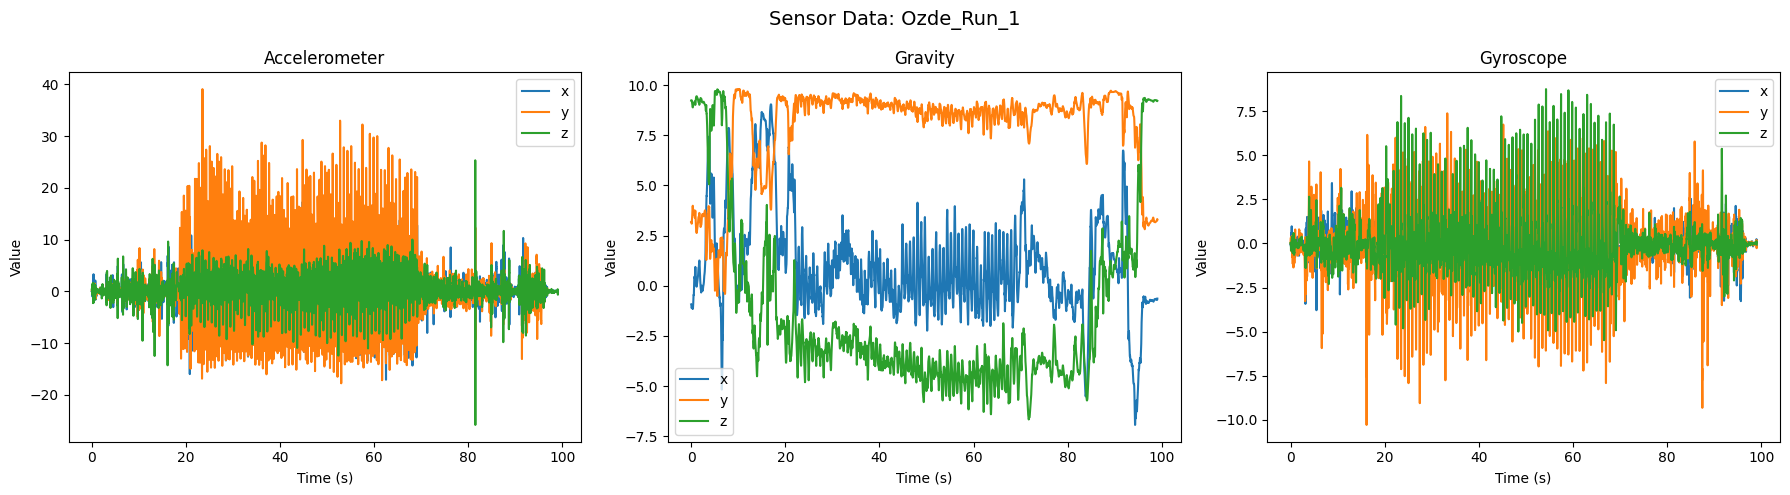

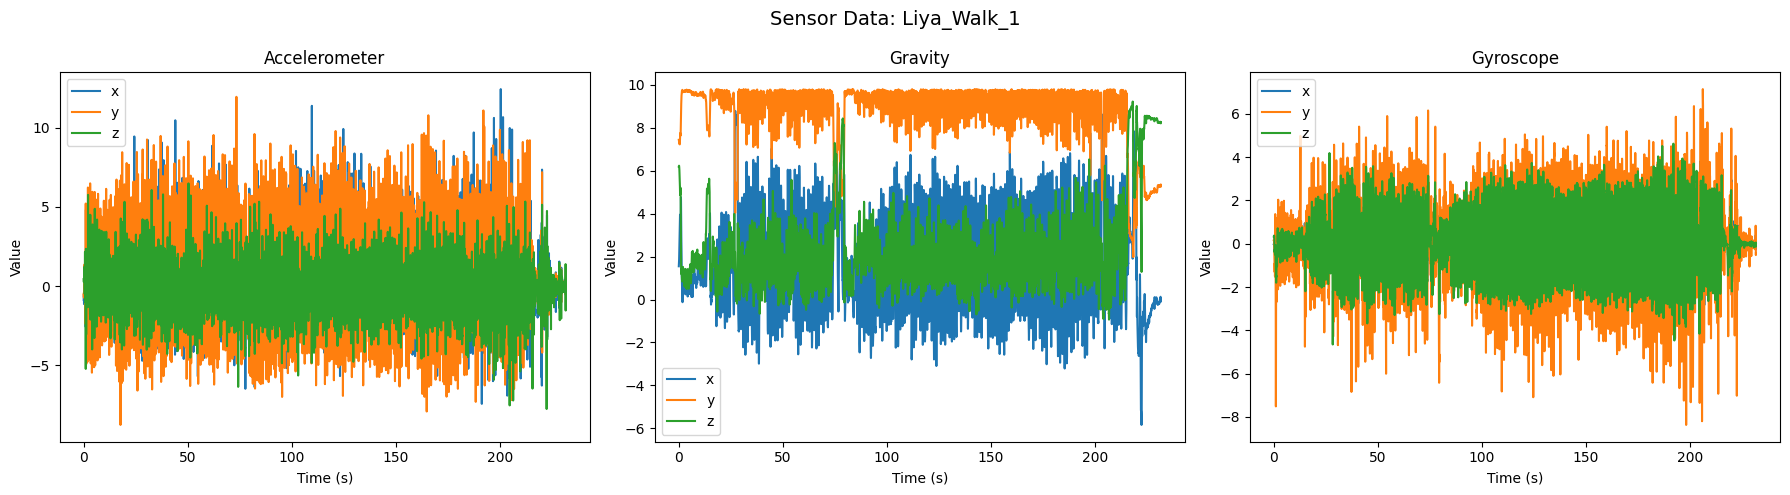

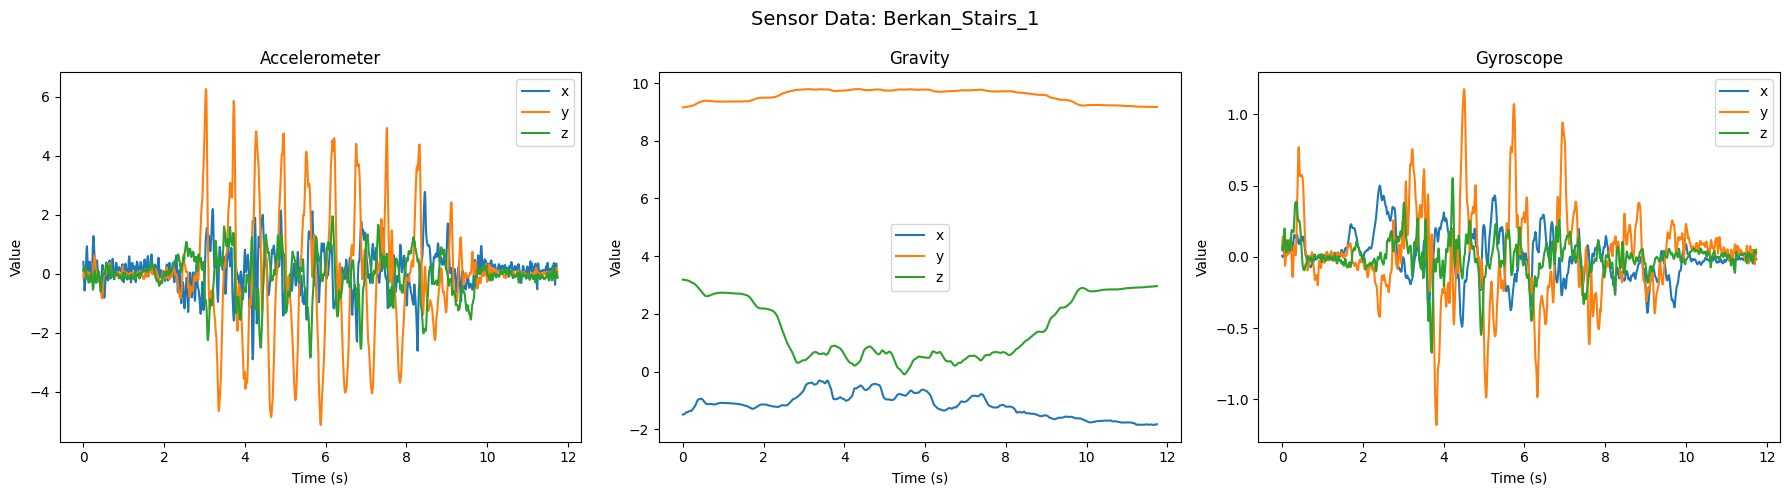

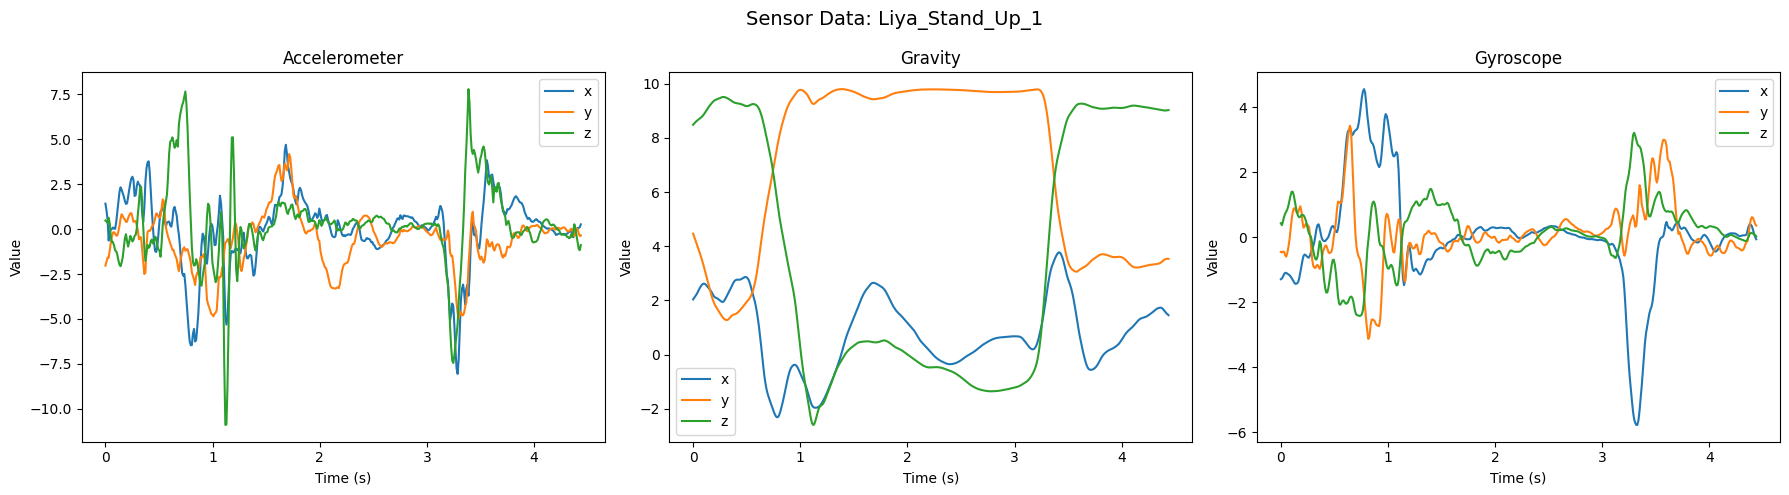

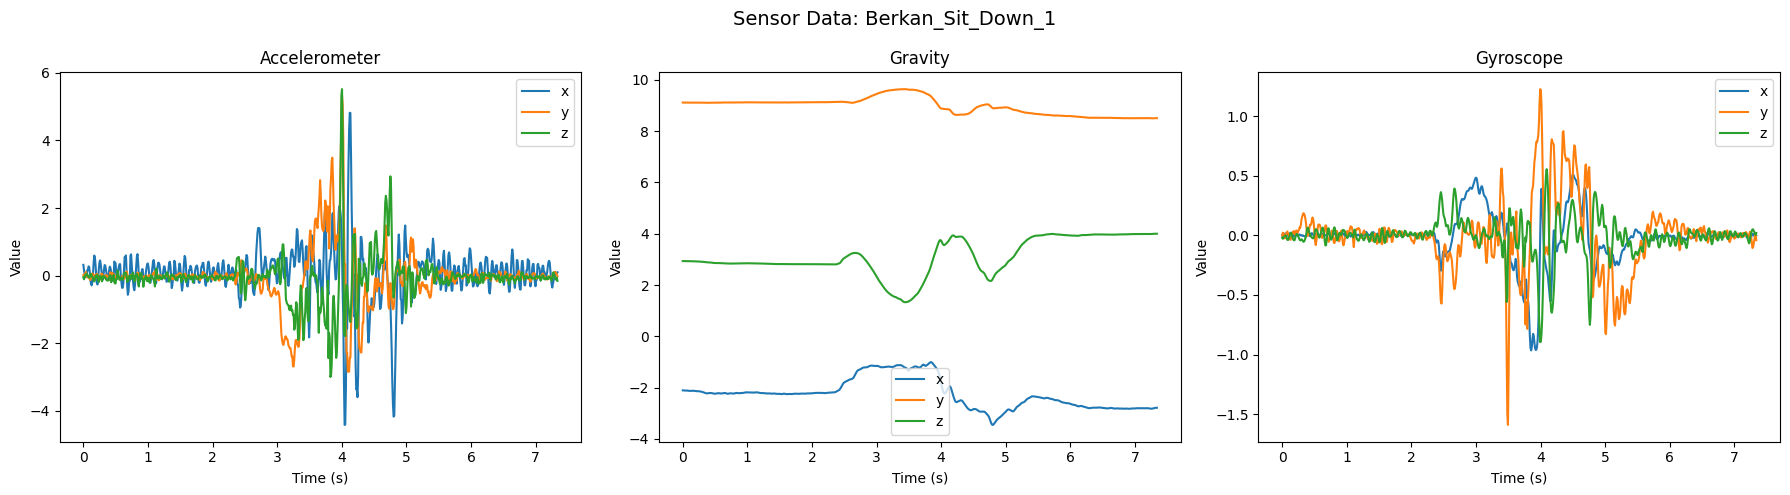

In [10]:
plot_activity(RAW_BASE / "running" / "Ozde_Run_1")
plot_activity(RAW_BASE / "walking" / "Liya_Walk_1")
plot_activity(RAW_BASE / "stairs" / "Berkan_Stairs_1")
plot_activity(RAW_BASE / "stand_up" / "Liya_Stand_Up_1")
plot_activity(RAW_BASE / "sit_down" / "Berkan_Sit_Down_1")

We start processing the raw data by first removing the inactive segments at the beginning and end of each recording, retaining only the portion where the activity is actually performed.
Additionally, we discard any segments recorded while placing the phone into the armband, as these movements do not represent the target activity.

- **For Continuous activities (running / walking / climbing stairs):** 
The preprocess_running, preprocess_walking, and preprocess_stairs functions all prepare the raw sensor recordings by detecting the active motion period and slicing it into fixed-length windows (3 s with 50% overlap). Each function first computes the RMS energy of the accelerometer (or gravity for stairs) to identify the start and end trim points, removing idle segments before and after the activity. Then, the trimmed data is split into overlapping windows for consistent input to later feature extraction and modeling. For walking and running, trimming is based on the accelerometer’s vertical axis, while for stairs it uses the gravity signal for more stable detection. These functions also generate plots showing the trimmed segments and shaded windows to visually verify the preprocessing steps.

In [11]:
WINDOW_SIZE = 3.0 #Seconds

# change show_plots to True to visualize the preprocessing steps

preprocess_running(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_walking(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_stairs(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False)  # show_plots=False to disable plots


 Processing running | Folder: Ozde_Run_1
  Trim 20.96 → 67.26, 29 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Liya_Run_2
  Trim 8.99 → 159.71, 99 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Berkan_Run_2
  Trim 7.51 → 67.41, 39 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Ozde_Run_3
  Trim 19.47 → 80.70, 39 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Ozde_Run_4
  Trim 17.98 → 79.21, 39 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_da

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Running Recordings:

![](figures\running_rms_intersection_based_trim_detection.png)

During motion (like walking or running), the accelerometer RMS is higher than during rest.
By sliding a window over the signal and comparing its RMS to these thresholds, we can automatically trim away the idle periods before and after the actual activity.

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Walking Recordings:

![](figures\walking_rms_intersection_based_trim_detection.png)



The corresponding accelerometer plots with the trims marked based on the RMS plot analysis. It can be seen that the trims capture the main activity by capturing the central part of the accelerometer data and leaving out the noise present at the start and end.

Walking:

![](figures/walk_rms.jpg)

![](figures/walk_acc.jpg)

Running: 

![](figures/run_rms.jpg)

![](figures/run_acc.jpg)

Stairs:

![](figures/rms_intersection.png)

![](figures/stairs_overlap.png)



- **For single-instance activities (sit-down / stand-up):**
Each single-instance activity (sit-down / stand-up) was trimmed to a 3-second window, centered on the activity itself, to remove non-activity segments. As before, we base this on the activity’s total energy.

In [12]:
WINDOW_SIZE = 3.0 #Seconds

results = trim_sitdown_standup(RAW_BASE, TRIMMED_BASE, window_size=WINDOW_SIZE)

Done. Processed: 194 | Skipped: 3


The trimming process for siting down and standing up functions:

- looping over both activities
- normalizing each recording's timestamps so they all start at 0.
- the trim is detected by analyzing the y-axis of the gravity sensor since it clearly shifts between the transitioning of the movements sitting and standing up.
- RMS calculation over hort windows is claculated and treshold values are defined for the start and end of the trim which are used to make the necessery cuts.

Now we can collect all windowed activity data into a single CSV file.

Using the windowed x, y, and z-axis recordings from the three sensors, we extracted the following features: acc_corr_x_y, acc_corr_x_z, acc_corr_y_z, acc_mag_dom_freq, acc_mag_iqr, acc_mag_kurtosis, acc_mag_max, acc_mag_mean, acc_mag_median, acc_mag_min, acc_mag_rms, acc_mag_skew, acc_mag_spec_centroid, acc_mag_spec_energy, acc_mag_spec_entropy, acc_mag_std, …, gyro_y_spec_entropy, gyro_y_std, gyro_z_dom_freq, gyro_z_iqr, gyro_z_kurtosis, gyro_z_max, gyro_z_mean, gyro_z_median, gyro_z_min, gyro_z_rms, gyro_z_skew, gyro_z_spec_centroid, gyro_z_spec_energy, gyro_z_spec_entropy, and gyro_z_std. 

which corresponds to 165 features per windowed sample.

These samples were compiled into a dataset for subsequent analysis and modeling.

In [13]:
#from create_csv import *

DATASET_PATH = PROJECT_ROOT / "dataset.csv"

audit_windows(TRIMMED_BASE)
df = build_dataset_from_windowed_data(TRIMMED_BASE, DATASET_PATH, keep_ids=True)

[Audit]
  - running: expected=439, usable=439, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - sit_down: expected=96, usable=96, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stairs: expected=82, usable=82, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stand_up: expected=98, usable=98, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - walking: expected=481, usable=481, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}

Total window folders: 1196 | Usable (all three files OK): 1196

[Activity] running
  Processed 250 windows...

[Activity] sit_down
  Processed 500 windows...

[Activity] stairs

[Activity] stand_up

[Activity] walking
  Processed 750 windows...
  Processed 1000 windows...

[Done] Wrote

## Load the dataset
- First column is label (y)
- Remaining are features (X)
- The last column includes the name of the person that recorded the data (used for stratification).

In [15]:
DATASET_PATH = PROJECT_ROOT / "dataset.csv"

df = pd.read_csv(DATASET_PATH)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print("Loaded dataset.csv with shape:", df.shape)
print("Target name:", df.columns[0])
print("Num features:", (X.shape[1]-1) )

df.head(3)# 12345

Loaded dataset.csv with shape: (1196, 167)
Target name: activity
Num features: 165


,activity,acc_corr_x_y,acc_corr_x_z,acc_corr_y_z,acc_mag_dom_freq,acc_mag_iqr,acc_mag_kurtosis,acc_mag_max,acc_mag_mean,acc_mag_median,...,gyro_z_mean,gyro_z_median,gyro_z_min,gyro_z_rms,gyro_z_skew,gyro_z_spec_centroid,gyro_z_spec_energy,gyro_z_spec_entropy,gyro_z_std,person
0,running,-0.422285,-0.255755,-0.025324,5.0,6.662222,-0.093018,23.414247,9.195592,9.040583,...,-0.017501,-0.035374,-1.221355,0.420798,0.278885,4.202507,11.759396,3.036354,0.421137,Berkan
1,running,-0.068380,-0.043782,-0.262769,5.0,5.756685,-0.737154,18.871659,9.020759,9.577971,...,0.038710,0.124412,-1.495412,0.619739,-0.194350,2.548933,19.232855,2.127987,0.619562,Berkan
2,running,-0.110942,0.009237,-0.290851,5.0,5.511045,-0.709310,17.660803,8.971730,9.589745,...,0.085773,0.187724,-1.495412,0.598747,-0.249874,2.659217,22.169449,2.251347,0.593562,Berkan


## Split data into Train and Test set
We split the data into training and test datsets with a 80/20 train/test ratio. This is done in a stratified manner. Afterwards we scale the data for effective training.


In [16]:
# imports
from sklearn.preprocessing import StandardScaler

X_train, y_train, X_test, y_test, info = stratified_person_label_split(X,y,test_ratio=0.20,random_state=42)

print(info["sizes"])
print(info["ratios"])
print("Classes:", info["class_dist"])
print("People:", info["person_dist"])

# --- StandardScaler setup ---
scaler = StandardScaler()

print(X_train.dtypes)
print(X_train.head())

# Keep only numeric columns
X_train_num = X_train.select_dtypes(include=["number"])
X_test_num  = X_test.select_dtypes(include=["number"])

# Scale numeric features only
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train.index)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test.index)


=== Pre-balance class counts ===
  Class running: 439 samples
  Class sit_down: 96 samples
  Class stairs: 82 samples
  Class stand_up: 98 samples
  Class walking: 481 samples
--> Target per-class size (minimum across classes): 82

Class running:
  Person counts BEFORE: {'Berkan': 77, 'Liya': 163, 'Ozde': 199}
  Person counts AFTER:  {'Berkan': 27, 'Liya': 27, 'Ozde': 28}
  -> Kept total for class running: 82 (target 82)

Class sit_down:
  Person counts BEFORE: {'Berkan': 35, 'Liya': 27, 'Ozde': 34}
  Person counts AFTER:  {'Berkan': 28, 'Liya': 27, 'Ozde': 27}
  -> Kept total for class sit_down: 82 (target 82)

Class stairs:
  Person counts BEFORE: {'Berkan': 30, 'Liya': 22, 'Ozde': 30}
  Person counts AFTER:  {'Berkan': 30, 'Liya': 22, 'Ozde': 30}
  -> Kept total for class stairs: 82 (target 82)

Class stand_up:
  Person counts BEFORE: {'Berkan': 35, 'Liya': 30, 'Ozde': 33}
  Person counts AFTER:  {'Berkan': 27, 'Liya': 28, 'Ozde': 27}
  -> Kept total for class stand_up: 82 (target 8

# Feature Selection
- **Filter Methods:** Variance -> Correlation -> Mutual Information
- **Wrapper Methods:** Recursive Feature Elimination (RFE) + Sequential Feature Selection (SFS) forward/backward

All performed on `dataset.csv` (explained above how this dataset is obtained).


In [17]:
## Imports & Code Paths 

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, cohen_kappa_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Paths & directories (safe to run multiple times)
# (Creates ./figures if it doesn't exist for saved plots)
os.makedirs("figures", exist_ok=True)


## Filter Methods
We use 3 filters succesively:
- **Variance:** Removes exactly-constant (dead) features
- **Correlation:** Drop one of each highly correlated pair of features
- **Mutual Information (MI):** Keep top-K features by MI with class labels 

In [16]:
# FILTERS: variance -> correlation -> MI-KBest
Xf_train, names_f, report = filter_select(
    X_train_scaled, y_train,
    variance_thresh=0.0,       #threshold for removing ONLY exactly-constant features
    corr_thresh=0.90,          #feature-feature absolute correlation threshold
    k_best=40,                 #integer: keep top-k by mutual information; None to skip
    scale_for_mi=True,         
    mi_n_neighbors=5,          #how many neighbors to use for MI selection
    mi_random_state=42         #fixed random_state for reproducibility
)
print("Filter report:", report)

# Apply same feature subset to both train and test
X_train_fs = X_train_scaled[names_f]
X_test_fs  = X_test_scaled[names_f]

[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 117, Removed: 48 (|r| > 0.9)
Removed highly correlated features: ['acc_mag_max', 'acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_spec_energy', 'acc_mag_std', 'acc_x_min', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_iqr', 'acc_z_median', 'acc_z_rms', 'acc_z_spec_energy', 'acc_z_std', 'grav_mag_rms', 'grav_mag_std', 'grav_x_median', 'grav_x_spec_energy', 'grav_x_std', 'grav_y_rms', 'grav_y_std', 'grav_z_mean', 'grav_z_median', 'grav_z_std', 'gyro_mag_mean', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_spec_energy', 'gyro_mag_std', 'gyro_x_std', 'gyro_y_iqr', 'gyro_y_max', 'gyro_y_min', 'gyro_y_rms', 'gyro_y_spec_energy', 'gyro_y_std', 'gyro_z_max', 'gyro_z_min', 'gyro_z_rms', 'gyro_z_spec_energy', 'gyro_z_std']
Correlated pairs (kept -> removed, r):
  acc_mag_iqr -> acc_mag_max (r=0.912)
  acc_mag_iqr -> acc_mag_mean

Baseline CV performance (5-fold, training set only):

LogisticRegression:
  Accuracy : 0.9394 ± 0.0287
  Kappa    : 0.9242 ± 0.0360
  F1-macro : 0.9399 ± 0.0278

KNN:
  Accuracy : 0.9030 ± 0.0312
  Kappa    : 0.8788 ± 0.0390
  F1-macro : 0.9026 ± 0.0308

NaiveBayes:
  Accuracy : 0.7697 ± 0.0337
  Kappa    : 0.7121 ± 0.0418
  F1-macro : 0.7604 ± 0.0305

DecisionTree:
  Accuracy : 0.8485 ± 0.0550
  Kappa    : 0.8105 ± 0.0688
  F1-macro : 0.8439 ± 0.0605


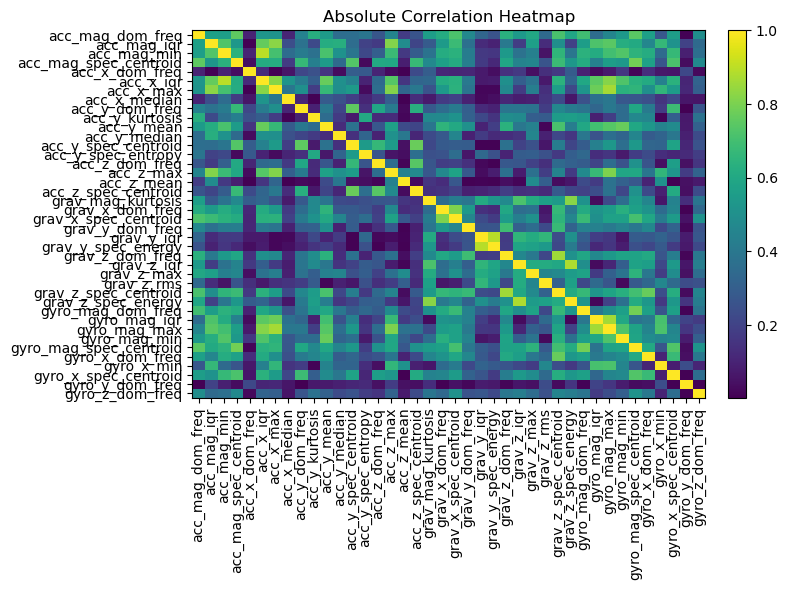

Saved correlation heatmap to corr_heatmap.png


In [17]:
#Intermediate Results
#Baseline models on filtered features (accuracy on held-out test set )
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

# Define custom scorers
scorers = {
    "accuracy": make_scorer(accuracy_score),
    "kappa": make_scorer(cohen_kappa_score),
    "f1_macro": make_scorer(f1_score, average="macro")  # macro for multiclass
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Baseline CV performance (5-fold, training set only):")
for name, clf in models.items():
    cv_results = cross_validate(clf, X_train_fs.values, y_train, cv=cv, scoring=scorers)
    acc_mean, acc_std = cv_results["test_accuracy"].mean(), cv_results["test_accuracy"].std()
    kappa_mean, kappa_std = cv_results["test_kappa"].mean(), cv_results["test_kappa"].std()
    f1_mean, f1_std = cv_results["test_f1_macro"].mean(), cv_results["test_f1_macro"].std()

    print(f"\n{name}:")
    print(f"  Accuracy : {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"  Kappa    : {kappa_mean:.4f} ± {kappa_std:.4f}")
    print(f"  F1-macro : {f1_mean:.4f} ± {f1_std:.4f}")

# Optional: visualize correlation after variance filtering
# Correlation heatmap (saved to figures/, non-blocking)
plot_correlation_heatmap(pd.DataFrame(Xf_train, columns=names_f), show=True, block=False, save_path="figures/corr_heatmap.png")
print("Saved correlation heatmap to corr_heatmap.png")

[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 133, Removed: 32 (|r| > 0.95)
Removed highly correlated features: ['acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_std', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_median', 'acc_z_rms', 'acc_z_std', 'grav_mag_rms', 'grav_mag_std', 'grav_x_median', 'grav_x_std', 'grav_y_rms', 'grav_z_mean', 'grav_z_median', 'grav_z_std', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_std', 'gyro_x_std', 'gyro_y_rms', 'gyro_y_std', 'gyro_z_spec_energy', 'gyro_z_std']
Correlated pairs (kept -> removed, r):
  acc_mag_max -> acc_mag_mean (r=0.957)
  acc_mag_mean -> acc_mag_median (r=0.994)
  acc_mag_iqr -> acc_mag_rms (r=0.960)
  acc_mag_max -> acc_mag_rms (r=0.967)
  acc_mag_mean -> acc_mag_rms (r=0.998)
  acc_mag_median -> acc_mag_rms (r=0.988)
  acc_mag_iqr -> acc_mag_std (r=0.975)
  acc_mag_max -> acc_mag_std (r=0.977)
  acc_mag_mean

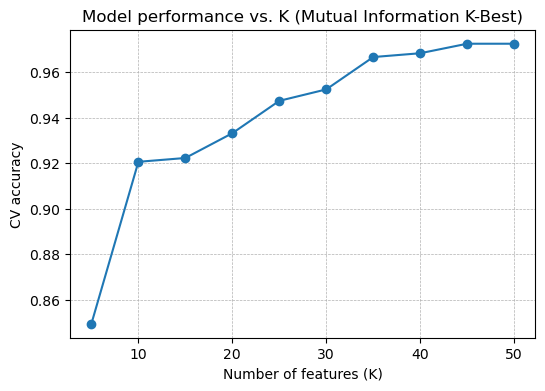

Saved MI K-curve to figures/mi_k_curve.png


In [18]:
# Keep only numeric features
X_num = X.select_dtypes(include=["number"])

# MI curve
ks, accs = accuracy_vs_k_MI(
    X_num, y,
    estimator=LogisticRegression(max_iter=2000, solver="lbfgs"),
    show=True, block=False, save_path="figures/mi_k_curve.png"
)
print("Saved MI K-curve to figures/mi_k_curve.png")

## Wrapper Methods
XXXXX

In [19]:
# Wrapper: RFE + Logistic Regression (CV summary on train only)
features_lr, info_lr = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    estimator=LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    cv_splits=5,
    choose_by="accuracy"
)

[RFE] k=40 start | Acc 0.9394 | F1m 0.9399 | Kappa 0.9242
[RFE] eliminated: grav_mag_kurtosis | k=39 | Acc 0.9364 | F1m 0.9369 | Kappa 0.9204
[RFE] eliminated: grav_y_dom_freq | k=38 | Acc 0.9364 | F1m 0.9369 | Kappa 0.9204
[RFE] eliminated: acc_x_median | k=37 | Acc 0.9394 | F1m 0.9399 | Kappa 0.9242
[RFE] eliminated: grav_y_spec_energy | k=36 | Acc 0.9394 | F1m 0.9399 | Kappa 0.9242
[RFE] eliminated: gyro_z_dom_freq | k=35 | Acc 0.9394 | F1m 0.9399 | Kappa 0.9242
[RFE] eliminated: gyro_mag_iqr | k=34 | Acc 0.9424 | F1m 0.9430 | Kappa 0.9280
[RFE] eliminated: gyro_x_dom_freq | k=33 | Acc 0.9424 | F1m 0.9430 | Kappa 0.9280
[RFE] eliminated: grav_x_dom_freq | k=32 | Acc 0.9364 | F1m 0.9367 | Kappa 0.9204
[RFE] eliminated: acc_z_mean | k=31 | Acc 0.9333 | F1m 0.9336 | Kappa 0.9166
[RFE] eliminated: acc_x_dom_freq | k=30 | Acc 0.9333 | F1m 0.9337 | Kappa 0.9166
[RFE] eliminated: grav_z_max | k=29 | Acc 0.9394 | F1m 0.9398 | Kappa 0.9242
[RFE] eliminated: grav_x_spec_centroid | k=28 | Acc 

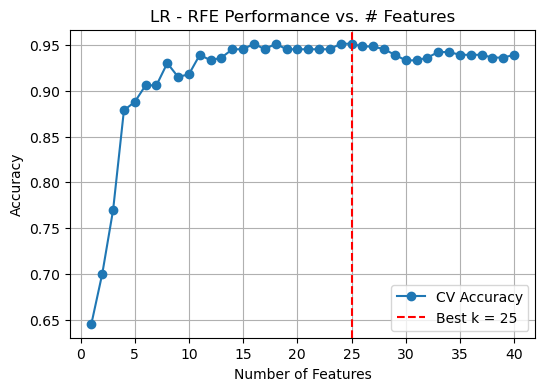

In [20]:
# Extract performance history
steps = [h["k"] for h in info_lr["history"]]
accs = [h["metrics"]["accuracy"][0] for h in info_lr["history"]]
best_k = info_lr["best"]["k"]

plt.figure(figsize=(6,4))
plt.plot(steps, accs, marker='o', linestyle='-', label='CV Accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title(f"LR - {info_lr['method'].upper()} Performance vs. # Features")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Wrapper: SFS (forward) + KNN (works well for distance-based models)
features_knn, info_knn = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    estimator=KNeighborsClassifier(n_neighbors=5),
    cv_splits=5,
    choose_by="accuracy"
)

[SFS:forward] added: acc_mag_spec_centroid | k=1 | Acc 0.6727 | F1m 0.6561 | Kappa 0.5905
[SFS:forward] added: acc_y_spec_entropy | k=2 | Acc 0.8364 | F1m 0.8342 | Kappa 0.7954
[SFS:forward] added: grav_z_max | k=3 | Acc 0.9061 | F1m 0.9058 | Kappa 0.8826
[SFS:forward] added: gyro_mag_iqr | k=4 | Acc 0.9364 | F1m 0.9364 | Kappa 0.9205
[SFS:forward] added: acc_mag_iqr | k=5 | Acc 0.9485 | F1m 0.9487 | Kappa 0.9356
[SFS:forward] added: acc_x_iqr | k=6 | Acc 0.9515 | F1m 0.9516 | Kappa 0.9394
[SFS:forward] added: acc_y_dom_freq | k=7 | Acc 0.9545 | F1m 0.9543 | Kappa 0.9432
[SFS:forward] added: grav_y_iqr | k=8 | Acc 0.9545 | F1m 0.9548 | Kappa 0.9432
[SFS:forward] added: acc_y_median | k=9 | Acc 0.9606 | F1m 0.9608 | Kappa 0.9507
[SFS:forward] added: acc_mag_dom_freq | k=10 | Acc 0.9667 | F1m 0.9666 | Kappa 0.9583
[SFS:forward] added: acc_y_spec_centroid | k=11 | Acc 0.9697 | F1m 0.9697 | Kappa 0.9621
[SFS:forward] added: acc_mag_min | k=12 | Acc 0.9697 | F1m 0.9697 | Kappa 0.9621
[SFS:f

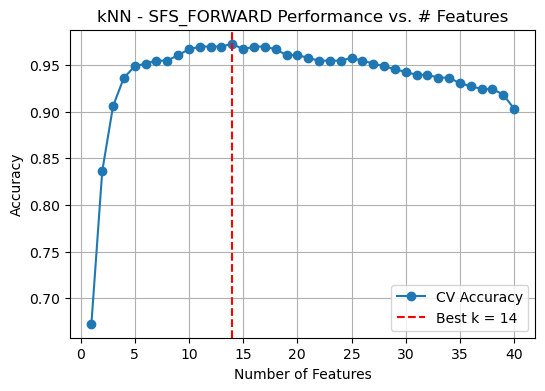

In [22]:
# Extract performance history
steps = [h["k"] for h in info_knn["history"]]
accs = [h["metrics"]["accuracy"][0] for h in info_knn["history"]]
best_k = info_knn["best"]["k"]

plt.figure(figsize=(6,4))
plt.plot(steps, accs, marker='o', linestyle='-', label='CV Accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title(f"kNN - {info_knn['method'].upper()} Performance vs. # Features")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Wrapper: SFS (forward) + Naive Bayes
features_nb, info_nb = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    estimator=GaussianNB(),
    cv_splits=5,
    choose_by="accuracy"
)

[SFS:forward] added: acc_mag_spec_centroid | k=1 | Acc 0.6606 | F1m 0.6180 | Kappa 0.5754
[SFS:forward] added: acc_y_median | k=2 | Acc 0.7697 | F1m 0.7626 | Kappa 0.7121
[SFS:forward] added: acc_y_spec_entropy | k=3 | Acc 0.8424 | F1m 0.8407 | Kappa 0.8030
[SFS:forward] added: acc_mag_iqr | k=4 | Acc 0.8697 | F1m 0.8677 | Kappa 0.8370
[SFS:forward] added: gyro_mag_dom_freq | k=5 | Acc 0.8818 | F1m 0.8797 | Kappa 0.8522
[SFS:forward] added: acc_z_mean | k=6 | Acc 0.8848 | F1m 0.8821 | Kappa 0.8560
[SFS:forward] added: grav_x_spec_centroid | k=7 | Acc 0.8879 | F1m 0.8861 | Kappa 0.8598
[SFS:forward] added: gyro_y_dom_freq | k=8 | Acc 0.8909 | F1m 0.8887 | Kappa 0.8636
[SFS:forward] added: grav_y_iqr | k=9 | Acc 0.8909 | F1m 0.8892 | Kappa 0.8636
[SFS:forward] added: grav_y_dom_freq | k=10 | Acc 0.8909 | F1m 0.8892 | Kappa 0.8636
[SFS:forward] added: grav_z_rms | k=11 | Acc 0.8909 | F1m 0.8901 | Kappa 0.8636
[SFS:forward] added: gyro_x_dom_freq | k=12 | Acc 0.8909 | F1m 0.8896 | Kappa 0.

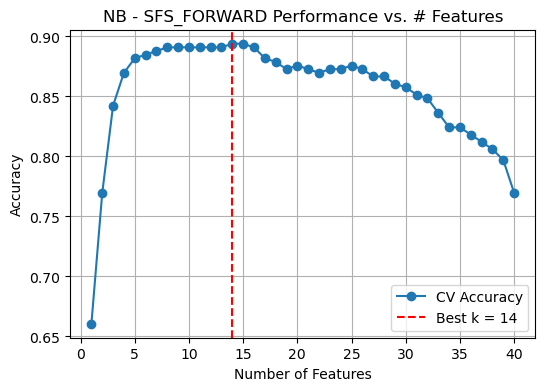

In [24]:
# Extract performance history
steps = [h["k"] for h in info_nb["history"]]
accs = [h["metrics"]["accuracy"][0] for h in info_nb["history"]]
best_k = info_nb["best"]["k"]

plt.figure(figsize=(6,4))
plt.plot(steps, accs, marker='o', linestyle='-', label='CV Accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title(f"NB - {info_nb['method'].upper()} Performance vs. # Features")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Wrapper: RFE + Decision Tree (trees don't need scaling)
features_dt, info_dt = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    estimator=DecisionTreeClassifier(random_state=42),
    cv_splits=5,
    choose_by="accuracy"
)

[RFE] k=40 start | Acc 0.8485 | F1m 0.8439 | Kappa 0.8105
[RFE] eliminated: acc_mag_dom_freq | k=39 | Acc 0.8242 | F1m 0.8202 | Kappa 0.7802
[RFE] eliminated: acc_x_median | k=38 | Acc 0.8333 | F1m 0.8321 | Kappa 0.7916
[RFE] eliminated: acc_x_iqr | k=37 | Acc 0.8485 | F1m 0.8438 | Kappa 0.8105
[RFE] eliminated: acc_y_dom_freq | k=36 | Acc 0.8455 | F1m 0.8410 | Kappa 0.8068
[RFE] eliminated: acc_y_kurtosis | k=35 | Acc 0.8364 | F1m 0.8319 | Kappa 0.7954
[RFE] eliminated: acc_y_median | k=34 | Acc 0.8394 | F1m 0.8351 | Kappa 0.7991
[RFE] eliminated: acc_z_dom_freq | k=33 | Acc 0.8485 | F1m 0.8447 | Kappa 0.8105
[RFE] eliminated: grav_x_dom_freq | k=32 | Acc 0.8485 | F1m 0.8443 | Kappa 0.8105
[RFE] eliminated: acc_z_mean | k=31 | Acc 0.8697 | F1m 0.8680 | Kappa 0.8371
[RFE] eliminated: grav_mag_kurtosis | k=30 | Acc 0.8424 | F1m 0.8406 | Kappa 0.8029
[RFE] eliminated: grav_y_dom_freq | k=29 | Acc 0.8667 | F1m 0.8661 | Kappa 0.8333
[RFE] eliminated: acc_z_max | k=28 | Acc 0.8545 | F1m 0.8

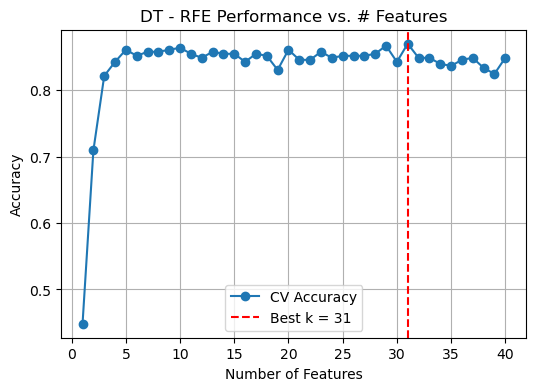

In [26]:
# Extract performance history
steps = [h["k"] for h in info_dt["history"]]
accs = [h["metrics"]["accuracy"][0] for h in info_dt["history"]]
best_k = info_dt["best"]["k"]

plt.figure(figsize=(6,4))
plt.plot(steps, accs, marker='o', linestyle='-', label='CV Accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title(f"DT - {info_dt['method'].upper()} Performance vs. # Features")
plt.legend()
plt.grid(True)
plt.show()

### Creating subsets with the selected features per model

In [27]:
# 1) Collect the per-model selected feature names
feature_sets = {
    "lr":  features_lr,   # from wrapper RFE + Logistic Regression
    "knn": features_knn,  # from wrapper SFS + KNN
    "nb":  features_nb,   # from wrapper SFS + Naive Bayes
    "dt":  features_dt,   # from wrapper RFE + Decision Tree
}

# 2) Create subsets directly (train/test; add val block if you have it)
X_train_lr = X_train_scaled[feature_sets["lr"]]
X_test_lr  = X_test_scaled[feature_sets["lr"]]

X_train_knn = X_train_scaled[feature_sets["knn"]]
X_test_knn  = X_test_scaled[feature_sets["knn"]]

X_train_nb = X_train_scaled[feature_sets["nb"]]
X_test_nb  = X_test_scaled[feature_sets["nb"]]

X_train_dt = X_train_scaled[feature_sets["dt"]]
X_test_dt  = X_test_scaled[feature_sets["dt"]]

print("Subset sizes (rows = samples, cols = features):")
print(f"  LR  → train: {X_train_lr.shape}, test: {X_test_lr.shape}")
print(f"  KNN → train: {X_train_knn.shape}, test: {X_test_knn.shape}")
print(f"  NB  → train: {X_train_nb.shape}, test: {X_test_nb.shape}")
print(f"  DT  → train: {X_train_dt.shape}, test: {X_test_dt.shape}")

Subset sizes (rows = samples, cols = features):
  LR  → train: (330, 25), test: (80, 25)
  KNN → train: (330, 14), test: (80, 14)
  NB  → train: (330, 14), test: (80, 14)
  DT  → train: (330, 31), test: (80, 31)


# Supervised Learning Methods

Different supervised learning methods are trained:
- A Logistic Regression model (LR)
- A Decision Tree (DT)
- A Naive Bayes classifier (NB)
- K-Nearest Neighbor algorithm (kNN)

Each of these is trained using their own subset of features which were selected during the feature selection phase.

Every model is trained using cross-validation adn is evaluated using the three scorers: Accuracy, Cohen's Kappa, and F1-score, as been done earlier in the notebook too.

For every model, their respective hyperparameters are tuned using gridsearch.

In [28]:
# CELL 1 — shared setup (run once)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Scorers: accuracy, Cohen's kappa, and macro-F1 for 5-class setup
scorers = {
    "accuracy": "accuracy",
    "kappa": make_scorer(cohen_kappa_score),
    "f1_macro": "f1_macro",
}

# pick one of these
refit_metric = "kappa"      
# refit_metric = "f1_macro"  
# refit_metric = "accuracy"  

# 5-fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def summarize_grid_search(gs):
    print("Best params:", gs.best_params_)
    print("Refit scorer:", gs.refit)
    print("Best CV score (refit metric):", gs.best_score_)

    # Show mean CV scores for all scorers at the best params
    means = gs.cv_results_["mean_test_accuracy"][gs.best_index_], \
            gs.cv_results_["mean_test_kappa"][gs.best_index_], \
            gs.cv_results_["mean_test_f1_macro"][gs.best_index_]
    print({"mean_accuracy": means[0], "mean_kappa": means[1], "mean_f1_macro": means[2]})


In [29]:
# CELL 2 — Logistic Regression
# Used model-specific training frame with 15 selected features

from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="lbfgs",
        #class_weight="balanced",
        random_state=42 ))
])

param_grid_lr = {
    "clf__C": np.logspace(-3, 2, 10),          # 0.001 ... 100
    "clf__max_iter": [500, 1000, 2000, 5000],  # convergence budget
}

gs_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_lr.fit(X_train_lr, y_train)
summarize_grid_search(gs_lr)

best_logreg = gs_lr.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'clf__C': np.float64(0.5994842503189409), 'clf__max_iter': 500}
Refit scorer: kappa
Best CV score (refit metric): 0.9393734943890543
{'mean_accuracy': np.float64(0.9515151515151515), 'mean_kappa': np.float64(0.9393734943890543), 'mean_f1_macro': np.float64(0.9514223740388659)}


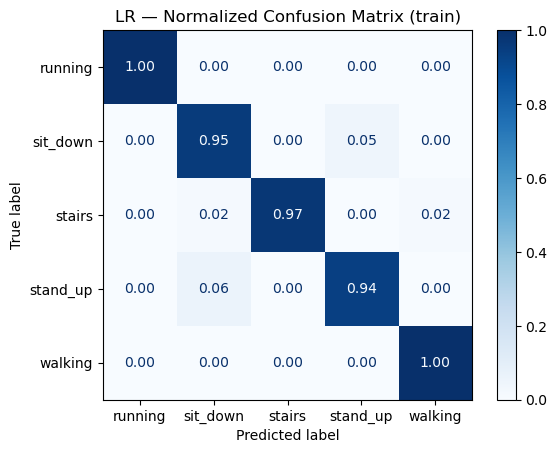

,feature,mean_abs_coef,mean_signed_coef
0,acc_y_spec_entropy,0.808647,8.881784e-17
1,acc_y_spec_centroid,0.622783,-4.884981e-16
2,acc_mag_spec_centroid,0.573312,-5.995204e-16
3,grav_z_rms,0.544970,-2.442491e-16
4,acc_x_max,0.521403,-5.884182e-16
5,acc_y_median,0.449808,3.996803e-16
6,acc_y_kurtosis,0.425307,-6.661338e-17
7,acc_mag_iqr,0.407450,-6.439294e-16
8,grav_z_iqr,0.393639,5.551115e-18
9,acc_mag_dom_freq,0.393061,-4.662937e-16


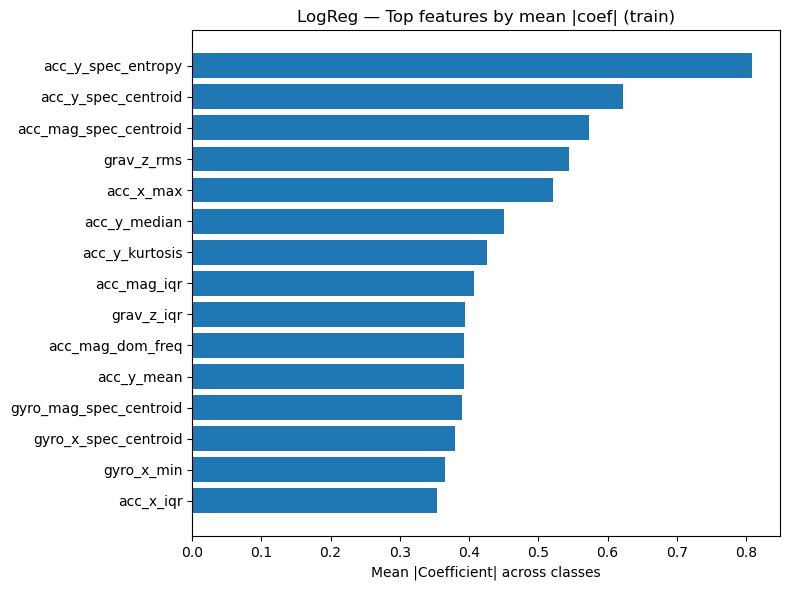

In [30]:
# Logistic Regression — train-set evaluation

from sklearn.metrics import ConfusionMatrixDisplay

# 1) Normalized confusion matrix (rows sum to 1)
ConfusionMatrixDisplay.from_estimator(
    best_logreg, X_train_lr, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("LR — Normalized Confusion Matrix (train)")
plt.show()

# 2) Mean coefficients across classes (top features)
lr = best_logreg.named_steps["clf"] if hasattr(best_logreg, "named_steps") else best_logreg
coefs = lr.coef_  # shape: (n_classes, n_features)

feature_names = list(getattr(X_train_lr, "columns", [f"f{i}" for i in range(coefs.shape[1])]))
mean_abs = np.mean(np.abs(coefs), axis=0)
mean_signed = np.mean(coefs, axis=0)

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_coef": mean_abs,
        "mean_signed_coef": mean_signed,
    })
    .sort_values("mean_abs_coef", ascending=False)
    .reset_index(drop=True)
)

# Show top 15
display(coef_df.head(15))

# bar plot for top features by mean |coef|
top = coef_df.head(15).sort_values("mean_abs_coef", ascending=True)
plt.figure(figsize=(8,6))
plt.barh(top["feature"], top["mean_abs_coef"])
plt.xlabel("Mean |Coefficient| across classes")
plt.title("LogReg — Top features by mean |coef| (train)")
plt.tight_layout()
plt.show()


In [31]:
# CELL 3 — Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None] + list(range(2, 31, 2)),
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

gs_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_dt.fit(X_train_dt, y_train)
summarize_grid_search(gs_dt)

best_dt = gs_dt.best_estimator_
tree_depth = best_dt.get_depth()

print("Depth:", tree_depth)
print("Leaves:", best_dt.get_n_leaves())


Fitting 5 folds for each of 512 candidates, totalling 2560 fits
Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Refit scorer: kappa
Best CV score (refit metric): 0.8559720332209114
{'mean_accuracy': np.float64(0.8848484848484848), 'mean_kappa': np.float64(0.8559720332209114), 'mean_f1_macro': np.float64(0.8818785726007373)}
Depth: 8
Leaves: 22


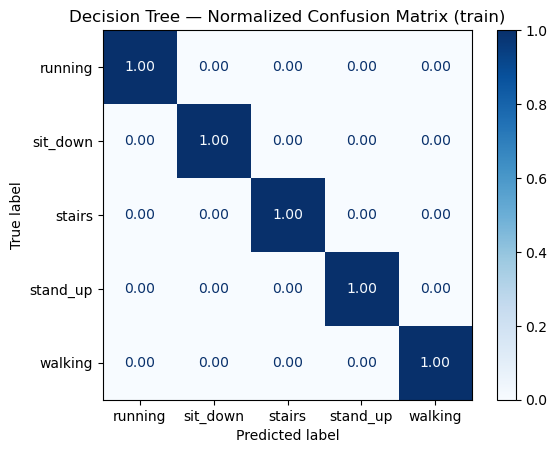

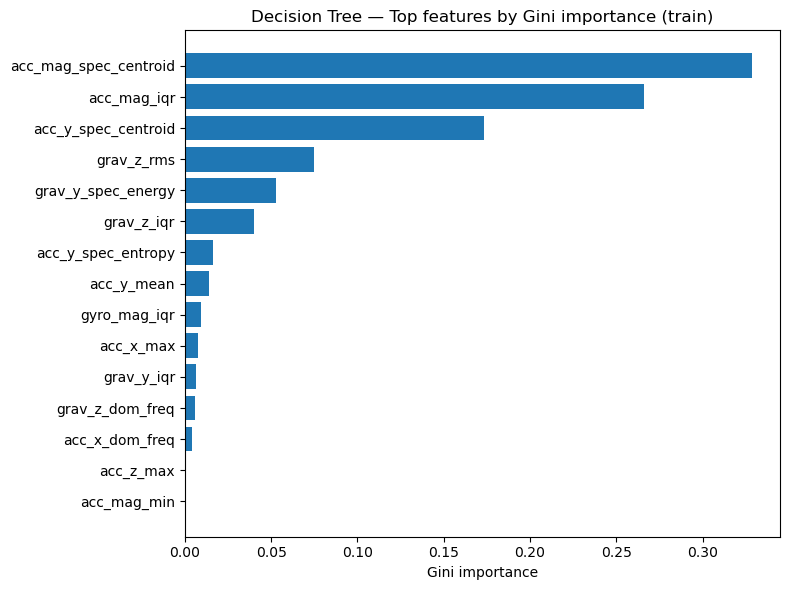

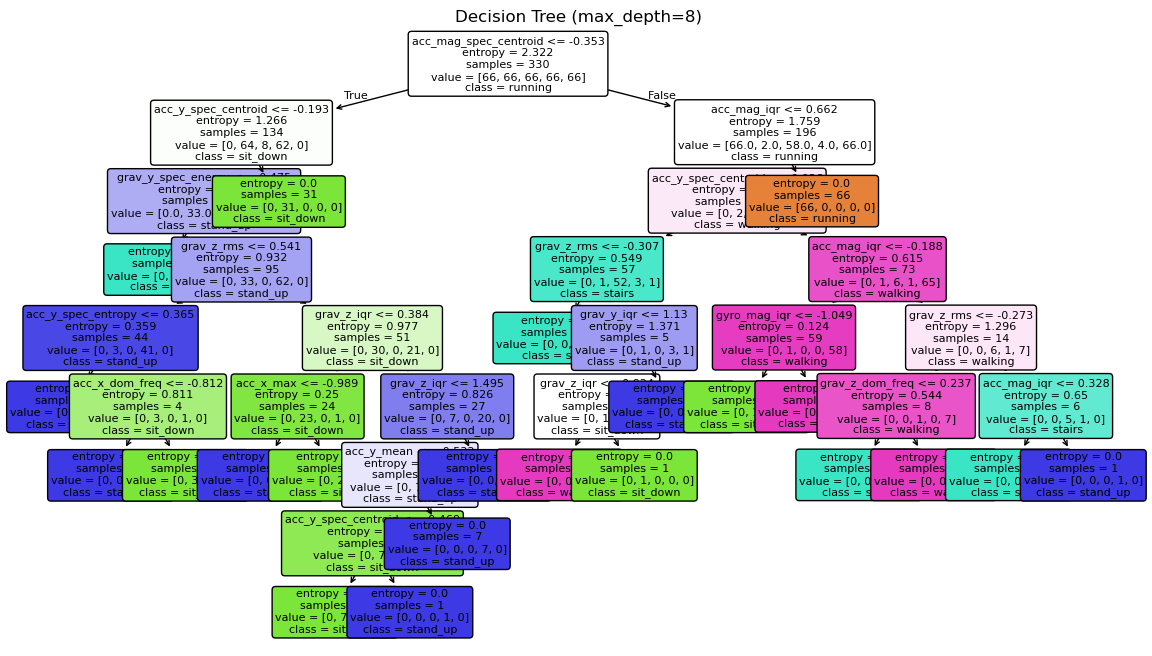

In [32]:
# Decision Tree — train-set evaluation 

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import tree as sktree

# 1) Normalized confusion matrix (rows sum to 1)
ConfusionMatrixDisplay.from_estimator(
    best_dt, X_train_dt, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("Decision Tree — Normalized Confusion Matrix (train)")
plt.show()

# 2) Gini importances + bar plot
dt = best_dt.named_steps["clf"] if hasattr(best_dt, "named_steps") else best_dt
feature_names = list(getattr(X_train_dt, "columns", [f"f{i}" for i in range(dt.n_features_in_)]))
imp = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=False)

# bar plot of top 15
top = imp.head(15).sort_values(ascending=True)
plt.figure(figsize=(8,6))
plt.barh(top.index, top.values)
plt.xlabel("Gini importance")
plt.title("Decision Tree — Top features by Gini importance (train)")
plt.tight_layout()
plt.show()

# 3) Visualize the tree 
# If you wish to visualize less levels than the full tree change max_depth to a integer number
plt.figure(figsize=(14, 8))
sktree.plot_tree(
    dt,
    feature_names=feature_names,
    class_names=[str(c) for c in dt.classes_],
    max_depth=tree_depth, filled=True, rounded=True, fontsize=8
)
plt.title(f"Decision Tree (max_depth={tree_depth})")
plt.show()



In [33]:
# CELL 4 — Naive Bayes (Gaussian)
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

param_grid_gnb = {
    "var_smoothing": np.logspace(-12, -6, 7)  # 1e-12 ... 1e-6
}

gs_gnb = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid_gnb,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_gnb.fit(X_train_nb, y_train)
summarize_grid_search(gs_gnb)

best_gnb = gs_gnb.best_estimator_

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best params: {'var_smoothing': np.float64(1e-12)}
Refit scorer: kappa
Best CV score (refit metric): 0.8673534571966129
{'mean_accuracy': np.float64(0.8939393939393939), 'mean_kappa': np.float64(0.8673534571966129), 'mean_f1_macro': np.float64(0.8931054428685966)}


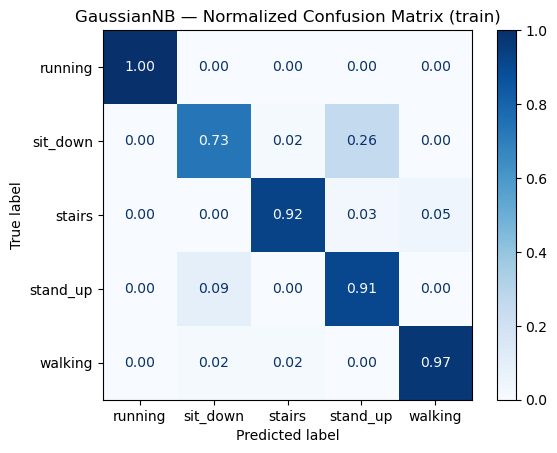

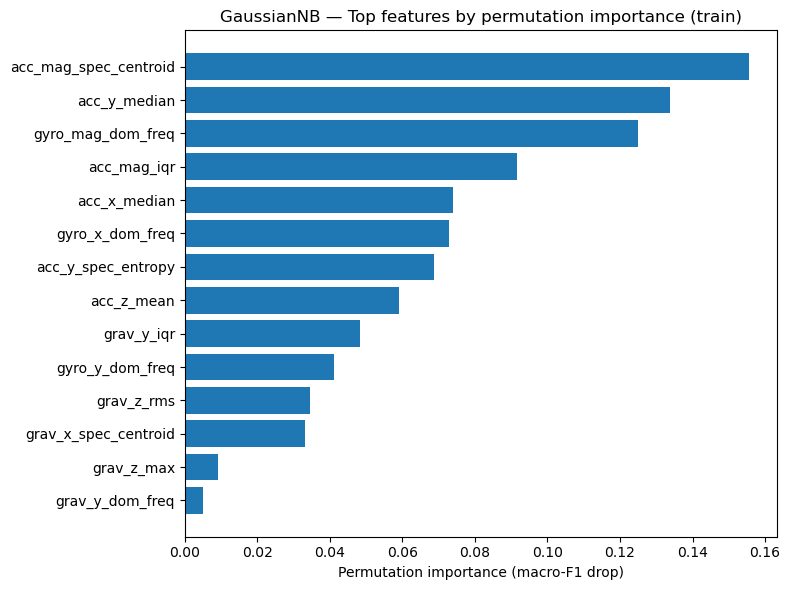

In [34]:
# Gaussian Naive Bayes — train-set evaluation

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# 1) Normalized confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_gnb, X_train_nb, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("GaussianNB — Normalized Confusion Matrix (train)")
plt.show()

# 2) Permutation importance (macro-F1) on train set
result = permutation_importance(
    best_gnb, X_train_nb, y_train,
    n_repeats=20, random_state=42, n_jobs=-1,
    scoring="f1_macro"
)

pi_mean = pd.Series(result.importances_mean, index=list(getattr(X_train_nb, "columns", None)))
pi_std  = pd.Series(result.importances_std,  index=list(getattr(X_train_nb, "columns", None)))
pi_df = (pd.DataFrame({"importance_mean": pi_mean, "importance_std": pi_std})
           .sort_values("importance_mean", ascending=False))

# bar plot of top 15
top = pi_df.head(15).sort_values("importance_mean", ascending=True)
plt.figure(figsize=(8,6))
plt.barh(top.index, top["importance_mean"])
plt.xlabel("Permutation importance (macro-F1 drop)")
plt.title("GaussianNB — Top features by permutation importance (train)")
plt.tight_layout()
plt.show()


In [35]:
# CELL 5 — KNN
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

param_grid_knn = {
    "clf__n_neighbors": list(range(1, 36, 2)),
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],  # 1=Manhattan, 2=Euclidean
}

gs_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_knn.fit(X_train_knn, y_train)
summarize_grid_search(gs_knn)

best_knn = gs_knn.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'clf__n_neighbors': 5, 'clf__p': 2, 'clf__weights': 'uniform'}
Refit scorer: kappa
Best CV score (refit metric): 0.9658947343431299
{'mean_accuracy': np.float64(0.9727272727272727), 'mean_kappa': np.float64(0.9658947343431299), 'mean_f1_macro': np.float64(0.9726630850630851)}


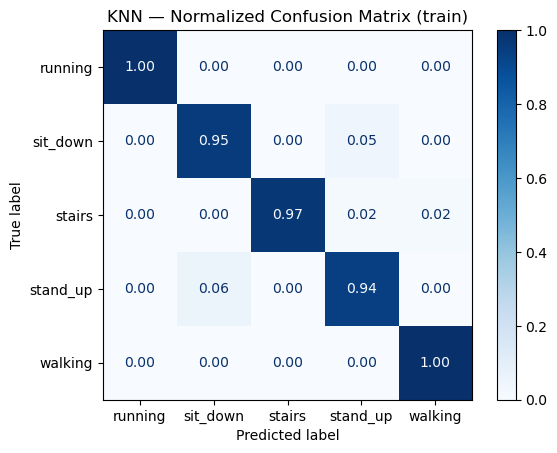

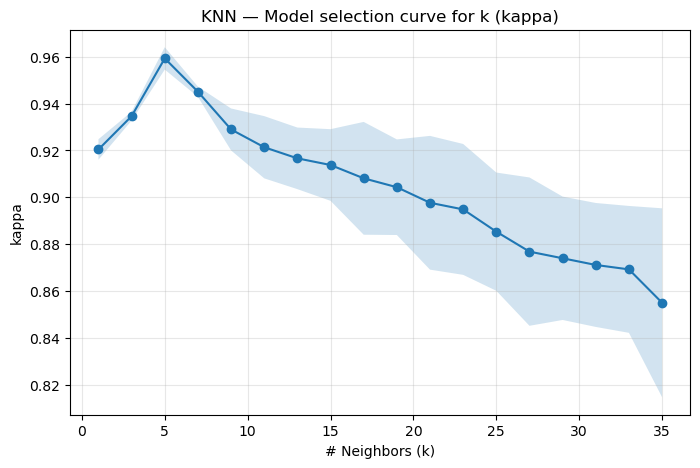

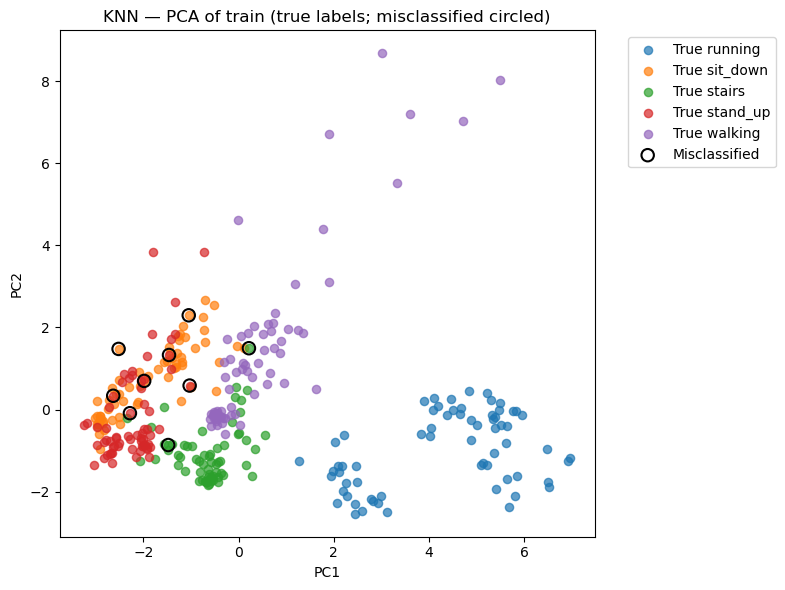

In [36]:
# KNN — train-set evaluation

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# 1) Normalized confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_knn, X_train_knn, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("KNN — Normalized Confusion Matrix (train)")
plt.show()

# 2) Model selection curve for n_neighbors using the refit metric
cvres = pd.DataFrame(gs_knn.cv_results_)
metric = gs_knn.refit  # e.g., "kappa" or "f1_macro"
col = f"mean_test_{metric}"
nn_col = "param_clf__n_neighbors"

curve = (cvres
         .assign(n_neighbors=cvres[nn_col].astype(int))
         .groupby("n_neighbors")[col]
         .agg(["mean", "std"])
         .sort_index())

plt.figure(figsize=(8,5))
plt.plot(curve.index, curve["mean"], marker="o")
plt.fill_between(curve.index, curve["mean"]-curve["std"], curve["mean"]+curve["std"], alpha=0.2)
plt.xlabel("# Neighbors (k)")
plt.ylabel(metric)
plt.title(f"KNN — Model selection curve for k ({metric})")
plt.grid(True, alpha=0.3)
plt.show()

# 3) PCA (2D): true labels vs predicted; misclassified circled
pipe = best_knn  # Pipeline(scaler + KNN)
X_scaled = pipe.named_steps["scaler"].transform(X_train_knn)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

y_pred = pipe.predict(X_train_knn)

unique = np.unique(y_train)
colors = plt.get_cmap("tab10").colors
color_map = {cls: colors[i % len(colors)] for i, cls in enumerate(unique)}

plt.figure(figsize=(8,6))
for i, cls in enumerate(unique):
    mask = (y_train == cls)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=35, alpha=0.7, c=[color_map[cls]], label=f"True {cls}")

mis = (y_pred != y_train)
plt.scatter(X_pca[mis, 0], X_pca[mis, 1], s=80, facecolors="none", edgecolors="k",
            linewidths=1.5, label="Misclassified")

plt.title("KNN — PCA of train (true labels; misclassified circled)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Unsupervised Learning Methods

Different unsupervised learning methods are trained:
- K-Means Clustering
- Fuzzy C-Means Clustering
- Gaussian Mixture Models (GMMs)

In all unsupervised models, a wrapper method is first applied to iterate over candidate feature subsets. The subset selected through this process is then used to train the unsupervised models.

Every model is evaluated using the three scorers: Accuracy, Cohen's Kappa, and F1-score.

Convert Class Labels to Integers:

In [37]:
from sklearn.preprocessing import LabelEncoder

# Encode labels to integers for metrics
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)

### K-Means Clustering

K-Means Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for K-Means Clustering.

Step 1 | +acc_y_spec_centroid | cv_mean=0.576 ± 0.052
Step 2 | +acc_mag_spec_centroid | cv_mean=0.676 ± 0.031
Step 3 | +acc_mag_iqr | cv_mean=0.709 ± 0.047
Step 4 | +gyro_mag_spec_centroid | cv_mean=0.724 ± 0.046
Step 5 | +acc_y_median | cv_mean=0.712 ± 0.094
Step 6 | +grav_x_spec_centroid | cv_mean=0.736 ± 0.065
Step 7 | +grav_z_spec_energy | cv_mean=0.736 ± 0.104
Step 8 | +grav_z_iqr | cv_mean=0.712 ± 0.085
Step 9 | +gyro_y_dom_freq | cv_mean=0.730 ± 0.141
Step 10 | +acc_mag_min | cv_mean=0.758 ± 0.061
Step 11 | +grav_z_rms | cv_mean=0.742 ± 0.071
Step 12 | +acc_y_kurtosis | cv_mean=0.764 ± 0.085
Step 13 | +grav_z_spec_centroid | cv_mean=0.752 ± 0.134
Step 14 | +acc_x_dom_freq | cv_mean=0.712 ± 0.124
Step 15 | +acc_x_max | cv_mean=0.748 ± 0.083
Step 16 | +grav_x_dom_freq | cv_mean=0.727 ± 0.124
Step 17 | +acc_y_spec_entropy | cv_mean=0.736 ± 0.092
Step 18 | +gyro_x_min | cv_mean=0.745 ± 0.129
Step 19 | +acc_z_max | cv_mean=0.721 ± 0.078
Step 20 | +grav_y_spec_energy | cv_mean=0.730 ±

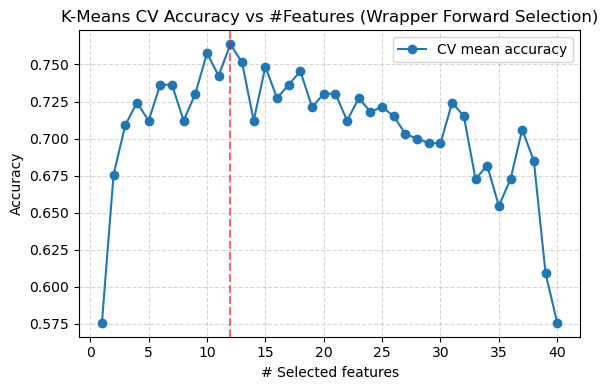

In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(y_true, y_pred):
    """Accuracy after optimal cluster↔class assignment via Hungarian algorithm."""
    n = max(len(np.unique(y_true)), len(np.unique(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n))
    r, c = linear_sum_assignment(cm.max() - cm)
    return cm[r, c].sum() / cm.sum()


def _kmeans_cv_score(X, y, subset, *, k, cv, random_state, kmeans_kwargs):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr_idx][subset].to_numpy(), X.iloc[va_idx][subset].to_numpy()
        y_va = y[va_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_va = scaler.transform(X_va)

        km = KMeans(n_clusters=k, **kmeans_kwargs, random_state=random_state)
        km.fit(X_tr)
        y_pred = km.predict(X_va)
        scores.append(cluster_accuracy(y_va, y_pred))

    scores = np.asarray(scores, dtype=float)
    return float(scores.mean()), float(scores.std(ddof=1) if len(scores) > 1 else 0.0)


def wrapper_kmeans_accuracy_cv(X_train: pd.DataFrame,
                               y_train: np.ndarray,
                               *,
                               k: int | None = None,
                               n_features_to_select: int = 15,
                               mode: str = "fixed",            # "fixed" → run full; "auto" → early stop on no-improve
                               random_state: int = 31,
                               kmeans_kwargs: dict | None = None,
                               select_set: int = 10,           # which step’s subset to RETURN (int) or "best"
                               cv: int = 5):
    if k is None:
        k = len(np.unique(y_train))
    if kmeans_kwargs is None:
        kmeans_kwargs = {}

    features = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))

    selected: list[str] = []
    history: list[dict] = []

    for step in range(1, max_steps + 1):
        trial_scores = []  # (cv_mean, feature, cv_std)

        for f in features:
            if f in selected:
                continue

            subset = selected + [f]
            cv_mean, cv_std = _kmeans_cv_score(
                X_train, y_train, subset, k=k, cv=cv,
                random_state=random_state, kmeans_kwargs=kmeans_kwargs
            )
            trial_scores.append((cv_mean, f, cv_std))

        if not trial_scores:
            break

        # pick feature that maximizes CV mean accuracy this step
        trial_scores.sort(key=lambda t: t[0], reverse=True)
        cv_mean, best_f, cv_std = trial_scores[0]
        selected.append(best_f)

        history.append({
            "step": step,
            "feature_added": best_f,
            "cv_mean": float(cv_mean),
            "cv_std": float(cv_std),
        })

        print(f"Step {step} | +{best_f} | cv_mean={cv_mean:.3f} ± {cv_std:.3f}")

        if mode == "auto":
            prev = history[-2]["cv_mean"] if len(history) > 1 else -np.inf
            if cv_mean <= prev:
                print("No improvement on CV mean; early stop.")
                break

    # Choose subset to RETURN
    if select_set == "best":
        chosen_step = int(np.argmax([h["cv_mean"] for h in history])) + 1
    elif isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        chosen_step = len(history)

    chosen_features = [h["feature_added"] for h in history][:chosen_step]
    chosen_cv_mean = history[chosen_step - 1]["cv_mean"]

    X_train_best = X_train[chosen_features]

    return X_train_best, chosen_features, float(chosen_cv_mean), history


X_train_km_best, subset_km, best_cv, hist = wrapper_kmeans_accuracy_cv(X_train_fs, 
                                                                    y_train_num,
                                                                    k=5,
                                                                    n_features_to_select=40,
                                                                    mode="fixed",
                                                                    random_state=42,
                                                                    kmeans_kwargs={"n_init": "auto", "max_iter": 300},
                                                                    select_set=12,     # or "best"
                                                                    cv=5)

# Extract same features from the test set
X_test_km_best = X_test_fs[subset_km]

print("Best subset:", subset_km)
print("Best CV mean accuracy:", best_cv)

# Plot: CV mean only
steps = [h["step"] for h in hist]
cv_means = [h["cv_mean"] for h in hist]
cv_stds  = [h["cv_std"] for h in hist]

plt.figure(figsize=(6,4))
plt.plot(steps, cv_means, marker='o', label="CV mean accuracy")
sel = len(subset_km)  # equals chosen_step
plt.axvline(sel, linestyle="--", alpha=0.6, color="red")
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("K-Means CV Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Using the reduced subset of features we train the K-Means Clustering Model

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'km__algorithm': 'lloyd', 'km__max_iter': 300, 'km__n_clusters': 5, 'km__n_init': 5}
Best CV Accuracy: 0.6545 ± 0.0993
Best CV F1: 0.5911 ± 0.1231
Best CV Kappa:     0.5679 ± 0.1241


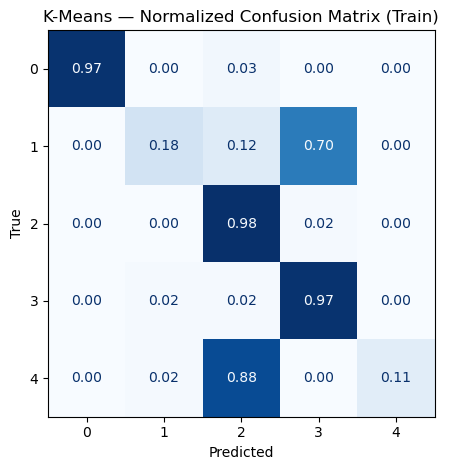

In [ ]:
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, cohen_kappa_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# helper functions
def hungarian_alignment(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = max(len(np.unique(y_true)), len(np.unique(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n))
    r, c = linear_sum_assignment(cm.max() - cm)   # r: true rows, c: pred cols
    mapping = dict(zip(c, r))                     # cluster (pred) -> class (true)
    return np.vectorize(lambda z: mapping.get(z, z))(y_pred)


def cluster_metric_scorer(metric_fn):
    """
    Returns a callable scorer(estimator, X, y) that:
      - predicts clusters
      - aligns them to true labels
      - computes the metric on aligned labels
    """
    def _score(estimator, X, y):
        y_pred = estimator.predict(X)
        y_pred_aligned = hungarian_alignment(y, y_pred)
        return metric_fn(y, y_pred_aligned)
    return _score

# Individual metric scorers
accuracy_scorer = cluster_metric_scorer(accuracy_score)
f1_macro_scorer = cluster_metric_scorer(lambda yt, yp: f1_score(yt, yp, average="macro"))
kappa_scorer    = cluster_metric_scorer(cohen_kappa_score)

# ----- Pipeline -----
pipe_km = Pipeline([
    ("scaler", StandardScaler()),
    ("km", KMeans(init="k-means++", random_state=42))
])

# ----- Hyperparameters -----
param_grid_km = {
    "km__n_clusters": [5],
    "km__n_init": [5, 10],
    "km__max_iter": [300, 600],
    "km__algorithm": ["lloyd", "elkan"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ----- GridSearch -----
gs_km = GridSearchCV(
    estimator=pipe_km,
    param_grid=param_grid_km,
    scoring={
        "accuracy": accuracy_scorer,
        "f1":       f1_macro_scorer,
        "kappa":    kappa_scorer,
    },
    refit="f1",     # pick which metric to refit on
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

# ----- Fit -----
gs_km.fit(X_train_km_best, y_train_num)

# ----- Summary -----
best_idx = gs_km.best_index_
cvres = gs_km.cv_results_

print("Best params:", gs_km.best_params_)
print(f"Best CV Accuracy: {cvres['mean_test_accuracy'][best_idx]:.4f} ± {cvres['std_test_accuracy'][best_idx]:.4f}")
print(f"Best CV F1: {cvres['mean_test_f1'][best_idx]:.4f} ± {cvres['std_test_f1'][best_idx]:.4f}")
print(f"Best CV Kappa: {cvres['mean_test_kappa'][best_idx]:.4f} ± {cvres['std_test_kappa'][best_idx]:.4f}")

best_kmeans = gs_km.best_estimator_

# ---------- Train CM ----------
y_pred_tr = best_kmeans.predict(X_train_km_best)
y_pred_tr_aligned = hungarian_alignment(y_train_num, y_pred_tr)

ConfusionMatrixDisplay.from_predictions(
    y_train_num, y_pred_tr_aligned,
    normalize="true", cmap="Blues", values_format=".2f", colorbar=False
)
plt.title("K-Means — Normalized Confusion Matrix (Train)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

### Fuzzy C-Means Clustering

Fuzzy C-Means Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for Fuzzy C-Means Clustering.

Step 1 | +acc_y_spec_centroid | cv_mean=0.594 ± 0.054
Step 2 | +acc_mag_iqr | cv_mean=0.682 ± 0.057
Step 3 | +grav_z_spec_energy | cv_mean=0.779 ± 0.041
Step 4 | +acc_mag_spec_centroid | cv_mean=0.809 ± 0.041
Step 5 | +acc_y_kurtosis | cv_mean=0.824 ± 0.035
Step 6 | +grav_y_spec_energy | cv_mean=0.830 ± 0.047
Step 7 | +acc_y_median | cv_mean=0.827 ± 0.030
Step 8 | +gyro_x_spec_centroid | cv_mean=0.833 ± 0.037
Step 9 | +gyro_y_dom_freq | cv_mean=0.836 ± 0.029
Step 10 | +acc_mag_min | cv_mean=0.842 ± 0.030
Step 11 | +acc_x_dom_freq | cv_mean=0.839 ± 0.017
Step 12 | +acc_y_dom_freq | cv_mean=0.845 ± 0.029
Step 13 | +gyro_mag_spec_centroid | cv_mean=0.842 ± 0.028
Step 14 | +acc_y_spec_entropy | cv_mean=0.845 ± 0.027
Step 15 | +gyro_x_dom_freq | cv_mean=0.858 ± 0.023
Step 16 | +grav_z_dom_freq | cv_mean=0.858 ± 0.030
Step 17 | +grav_x_spec_centroid | cv_mean=0.861 ± 0.027
Step 18 | +grav_z_spec_centroid | cv_mean=0.858 ± 0.028
Step 19 | +grav_z_iqr | cv_mean=0.848 ± 0.030
Step 20 | +acc_mag

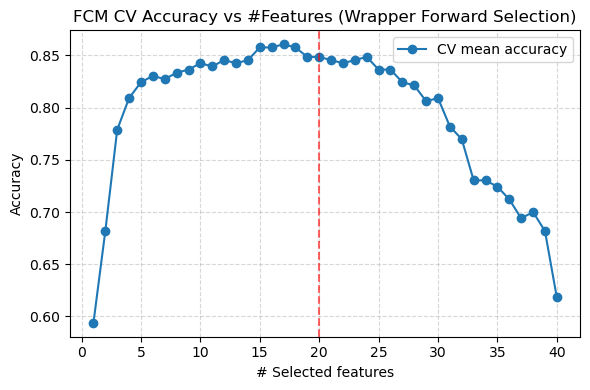

In [40]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import skfuzzy as fuzz

# ---------- FCM helpers ----------
def _fcm_memberships_from_centers(X, centers, m=2.0, eps=1e-12):
    """
    Compute FCM memberships for X given learned centers (no refit).
    Returns U with shape (c, n_samples).
    """
    X = np.asarray(X)
    C = np.asarray(centers)
    d = np.linalg.norm(X[None, :, :] - C[:, None, :], axis=2) + eps  # (c, n)

    exact = np.isclose(d, eps)
    if exact.any():
        U = np.zeros_like(d)
        closest = np.argmin(d, axis=0)
        U[closest, np.arange(X.shape[0])] = 1.0
        mask = (U.sum(axis=0) == 0)
        if mask.any():
            dm = d[:, mask]
            p = 2.0 / (m - 1.0)
            ratio = (dm[:, None, :] / dm[None, :, :]) ** p
            denom = ratio.sum(axis=1)
            U[:, mask] = 1.0 / denom
        return U

    p = 2.0 / (m - 1.0)
    ratio = (d[:, None, :] / d[None, :, :]) ** p
    denom = ratio.sum(axis=1)
    return 1.0 / denom


def _fcm_cv_score(X, y, subset, *, k, cv, random_state, m, error, maxiter):
    """
    Mean/std CV accuracy for FCM on a given feature subset.
    Fits FCM on train folds; predicts memberships on validation folds using learned centers.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    rng = np.random.RandomState(random_state) if random_state is not None else None

    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr = X.iloc[tr_idx][subset].to_numpy()
        X_va = X.iloc[va_idx][subset].to_numpy()
        y_va = y[va_idx]

        # scale within fold
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_va = scaler.transform(X_va)

        # skfuzzy expects (features, samples)
        Xtr_f = X_tr.T

        # reproducible soft-init U0
        if rng is not None:
            U0 = rng.rand(k, Xtr_f.shape[1])
            U0 /= U0.sum(axis=0, keepdims=True)
        else:
            U0 = None

        cntr, Utr, *_ = fuzz.cluster.cmeans(
            Xtr_f, c=k, m=m, error=error, maxiter=maxiter, init=U0
        )

        # predict on validation using learned centers
        Uva = _fcm_memberships_from_centers(X_va, cntr, m=m)
        y_pred = Uva.argmax(axis=0)
        scores.append(cluster_accuracy(y_va, y_pred))

    scores = np.asarray(scores, dtype=float)
    return float(scores.mean()), float(scores.std(ddof=1) if len(scores) > 1 else 0.0)


def wrapper_fcm_accuracy_cv(X_train: pd.DataFrame,
                            y_train: np.ndarray,
                            *,
                            k: int | None = None,
                            n_features_to_select: int = 15,
                            mode: str = "fixed",           # "fixed" → run full; "auto" → early stop on no-improve
                            random_state: int | None = 31,
                            select_set: int | str = 10,    # int step to return, or "best"
                            cv: int = 5,
                            m: float = 2.0,
                            error: float = 0.005,
                            maxiter: int = 1000):
    """
    Forward feature selection for FCM scored by cross-validated accuracy.
    Returns
    -------
    X_train_best : pd.DataFrame
    chosen_features : list[str]
    chosen_cv_mean : float
    history : list[dict] with keys {"step","feature_added","cv_mean","cv_std"}
    """
    if k is None:
        k = len(np.unique(y_train))

    features = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))

    selected: list[str] = []
    history: list[dict] = []

    for step in range(1, max_steps + 1):
        trial_scores = []  # (cv_mean, feature, cv_std)
        for f in features:
            if f in selected:
                continue
            subset = selected + [f]
            cv_mean, cv_std = _fcm_cv_score(
                X_train, y_train, subset,
                k=k, cv=cv, random_state=random_state,
                m=m, error=error, maxiter=maxiter,
            )
            trial_scores.append((cv_mean, f, cv_std))

        if not trial_scores:
            break

        trial_scores.sort(key=lambda t: t[0], reverse=True)
        cv_mean, best_f, cv_std = trial_scores[0]
        selected.append(best_f)
        history.append({
            "step": step,
            "feature_added": best_f,
            "cv_mean": float(cv_mean),
            "cv_std": float(cv_std),
        })
        print(f"Step {step} | +{best_f} | cv_mean={cv_mean:.3f} ± {cv_std:.3f}")

        if mode == "auto":
            prev = history[-2]["cv_mean"] if len(history) > 1 else -np.inf
            if cv_mean <= prev:
                print("No improvement on CV mean; early stop.")
                break

    # choose subset to return
    if select_set == "best":
        chosen_step = int(np.argmax([h["cv_mean"] for h in history])) + 1
    elif isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        chosen_step = len(history)

    chosen_features = [h["feature_added"] for h in history][:chosen_step]
    chosen_cv_mean = history[chosen_step - 1]["cv_mean"]
    X_train_best = X_train[chosen_features]

    return X_train_best, chosen_features, float(chosen_cv_mean), history


X_train_fcm_best, subset_fcm, best_cv_fcm, hist_fcm = wrapper_fcm_accuracy_cv(X_train_fs, 
                                                                              y_train_num,
                                                                              k=5,
                                                                              n_features_to_select=40,
                                                                              mode="fixed",
                                                                              random_state=31,
                                                                              select_set=20,   # or "best"
                                                                              cv=5,
                                                                              m=2.0,
                                                                              error=0.005,
                                                                              maxiter=1000)
# Extract same features from the test set
X_test_fcm_best = X_test_fs[subset_fcm]

print("Best subset (FCM):", subset_fcm)
print("Best CV mean accuracy (FCM):", best_cv_fcm)

# Plot CV mean only
steps = [h["step"] for h in hist_fcm]
cv_means = [h["cv_mean"] for h in hist_fcm]
cv_stds  = [h["cv_std"] for h in hist_fcm]

plt.figure(figsize=(6,4))
line, = plt.plot(steps, cv_means, marker='o', label="CV mean accuracy")
sel = len(subset_fcm)
plt.axvline(sel, linestyle="--", alpha=0.6, color="red")
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("FCM CV Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Using the reduced subset of features we train the Fuzzy C-Mean Clustering Model

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'fcm__error': 0.005, 'fcm__m': 2.2, 'fcm__max_iter': 300, 'fcm__n_clusters': 5}
Best CV Accuracy: 0.8485 ± 0.0332
Best CV F1: 0.8468 ± 0.0338
Best CV Kappa:     0.8105 ± 0.0415


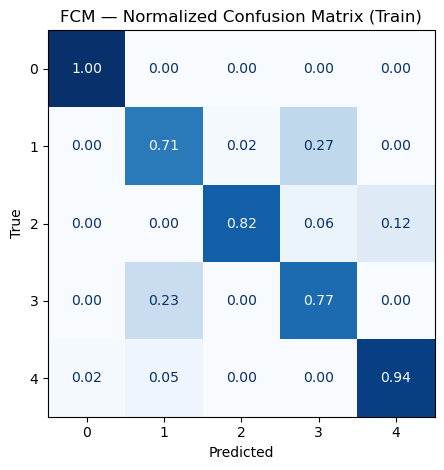

In [ ]:
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, cohen_kappa_score
)
import skfuzzy as fuzz

# FCM helpers
def _fcm_memberships_from_centers(X, centers, m=2.0, eps=1e-12):
    """
    Compute FCM memberships for X given learned centers (no refit).
    Returns U with shape (c, n_samples).
    """
    X = np.asarray(X)
    C = np.asarray(centers)
    # d[c, n]: distances center c to sample n
    d = np.linalg.norm(X[None, :, :] - C[:, None, :], axis=2) + eps

    # exact zero distances -> hard one-hot
    exact = np.isclose(d, eps)
    if exact.any():
        U = np.zeros_like(d)
        closest = np.argmin(d, axis=0)
        U[closest, np.arange(X.shape[0])] = 1.0
        mask = (U.sum(axis=0) == 0)
        if mask.any():
            dm = d[:, mask]
            p = 2.0 / (m - 1.0)
            ratio = (dm[:, None, :] / dm[None, :, :]) ** p
            denom = ratio.sum(axis=1)
            U[:, mask] = 1.0 / denom
        return U

    p = 2.0 / (m - 1.0)
    ratio = (d[:, None, :] / d[None, :, :]) ** p
    denom = ratio.sum(axis=1)
    return 1.0 / denom


# ---------- sklearn-compatible FCM estimator ----------
class FuzzyCMeans(BaseEstimator, ClusterMixin):
    """
    Minimal sklearn-style wrapper for skfuzzy.cmeans.
    - Fits on (n_samples, n_features) arrays
    - Stores centers_ and m_
    - predict() returns hard labels via argmax of memberships to learned centers
    """
    def __init__(self,
                 n_clusters=5,
                 m=2.0,
                 error=0.005,
                 max_iter=1000,
                 random_state=None):
        self.n_clusters = n_clusters
        self.m = m
        self.error = error
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        # skfuzzy expects (features, samples)
        Xf = X.T

        # reproducible soft init
        rng = None if self.random_state is None else np.random.RandomState(self.random_state)
        if rng is not None:
            U0 = rng.rand(self.n_clusters, Xf.shape[1])
            U0 /= U0.sum(axis=0, keepdims=True)
        else:
            U0 = None

        cntr, U, _, _, _, _, _ = fuzz.cluster.cmeans(
            Xf, c=self.n_clusters, m=self.m, error=self.error,
            maxiter=self.max_iter, init=U0
        )
        self.centers_ = cntr          # (c, d)
        self.m_ = self.m
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        U = _fcm_memberships_from_centers(X, self.centers_, m=self.m_)
        return U.argmax(axis=0)       # hard labels

accuracy_scorer = cluster_metric_scorer(accuracy_score)
f1_macro_scorer = cluster_metric_scorer(lambda yt, yp: f1_score(yt, yp, average="macro"))
kappa_scorer    = cluster_metric_scorer(cohen_kappa_score)

# ---------- Pipeline ----------
pipe_fcm = Pipeline([
    ("scaler", StandardScaler()),
    ("fcm", FuzzyCMeans(n_clusters=5, m=2.0, error=0.005, max_iter=1000, random_state=42))
])

# ---------- Hyperparameters to search ----------
param_grid_fcm = {
    "fcm__n_clusters": [5],     
    "fcm__m": [1.8, 2.0, 2.2],   # fuzziness
    "fcm__error": [0.01, 0.005], # stopping tolerance
    "fcm__max_iter": [300, 1000],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------- GridSearch ----------
gs_fcm = GridSearchCV(
    estimator=pipe_fcm,
    param_grid=param_grid_fcm,
    scoring={
        "accuracy": accuracy_scorer,
        "f1":       f1_macro_scorer,
        "kappa":    kappa_scorer,
    },
    refit="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

# ----- Fit -----
gs_fcm.fit(X_train_fcm_best, y_train_num)

# ----- Summary -----
best_idx = gs_fcm.best_index_
cvres = gs_fcm.cv_results_
print("Best params:", gs_fcm.best_params_)
print(f"Best CV Accuracy: {cvres['mean_test_accuracy'][best_idx]:.4f} ± {cvres['std_test_accuracy'][best_idx]:.4f}")
print(f"Best CV F1: {cvres['mean_test_f1'][best_idx]:.4f} ± {cvres['std_test_f1'][best_idx]:.4f}")
print(f"Best CV Kappa: {cvres['mean_test_kappa'][best_idx]:.4f} ± {cvres['std_test_kappa'][best_idx]:.4f}")

best_fcm = gs_fcm.best_estimator_

# ---------- Train CM ----------
y_pred_tr = best_fcm.predict(X_train_fcm_best)
y_pred_tr_aligned = hungarian_alignment(y_train_num, y_pred_tr)
ConfusionMatrixDisplay.from_predictions(
    y_train_num, y_pred_tr_aligned,
    normalize="true", cmap="Blues", values_format=".2f", colorbar=False
)
plt.title("FCM — Normalized Confusion Matrix (Train)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

### Gaussian Mixture Models (GMMs)

Gaussian Mixture Model Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for GMM.

Step 1 | +acc_y_spec_centroid | cv_mean=0.585 ± 0.014
Step 2 | +acc_y_kurtosis | cv_mean=0.652 ± 0.010
Step 3 | +acc_y_median | cv_mean=0.730 ± 0.050
Step 4 | +grav_z_rms | cv_mean=0.794 ± 0.026
Step 5 | +acc_y_mean | cv_mean=0.812 ± 0.029
Step 6 | +grav_z_iqr | cv_mean=0.773 ± 0.009
Step 7 | +grav_x_spec_centroid | cv_mean=0.761 ± 0.092
Step 8 | +gyro_x_spec_centroid | cv_mean=0.836 ± 0.033
Step 9 | +grav_y_iqr | cv_mean=0.776 ± 0.050
Step 10 | +acc_y_spec_entropy | cv_mean=0.724 ± 0.084
Step 11 | +grav_z_dom_freq | cv_mean=0.733 ± 0.073
Step 12 | +gyro_y_dom_freq | cv_mean=0.721 ± 0.053
Step 13 | +acc_mag_spec_centroid | cv_mean=0.748 ± 0.014
Step 14 | +gyro_mag_dom_freq | cv_mean=0.742 ± 0.064
Step 15 | +grav_z_spec_energy | cv_mean=0.752 ± 0.100
Step 16 | +grav_y_dom_freq | cv_mean=0.724 ± 0.113
Step 17 | +acc_x_max | cv_mean=0.709 ± 0.072
Step 18 | +grav_z_spec_centroid | cv_mean=0.670 ± 0.073
Step 19 | +acc_mag_dom_freq | cv_mean=0.658 ± 0.077
Step 20 | +grav_mag_kurtosis | cv_me

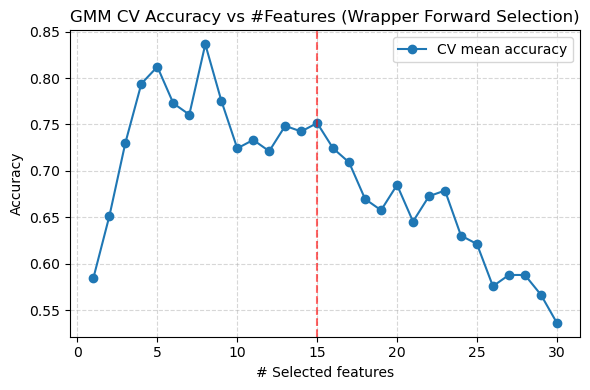

In [42]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold

# --- CV scorer for a given feature subset ---
def _gmm_cv_score(X, y, subset, *, k, cv, random_state, gmm_kwargs):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    scores = []

    for tr_idx, va_idx in skf.split(X, y):
        X_tr = X.iloc[tr_idx][subset].to_numpy()
        X_va = X.iloc[va_idx][subset].to_numpy()
        y_va = y[va_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_va = scaler.transform(X_va)

        gmm = GaussianMixture(n_components=k, random_state=random_state, **gmm_kwargs)
        gmm.fit(X_tr)
        y_pred = gmm.predict(X_va)          # argmax posterior
        scores.append(cluster_accuracy(y_va, y_pred))

    scores = np.asarray(scores, dtype=float)
    return float(scores.mean()), float(scores.std(ddof=1) if len(scores) > 1 else 0.0)


def wrapper_gmm_accuracy_cv(X_train: pd.DataFrame,
                            y_train: np.ndarray,
                            *,
                            k: int | None = None,
                            n_features_to_select: int = 15,
                            mode: str = "fixed",              # "auto" → early stop on no-improve
                            random_state: int = 42,
                            select_set: int | str = 10,       # step to return, or "best"
                            cv: int = 5,
                            gmm_kwargs: dict | None = None):
    """
    Forward feature selection for Gaussian Mixture Models scored by CV accuracy.

    Returns
    -------
    X_train_best, chosen_features, chosen_cv_mean, history
    """
    if k is None:
        k = len(np.unique(y_train))
    if gmm_kwargs is None:
        gmm_kwargs = {}

    features = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))

    selected: list[str] = []
    history: list[dict] = []

    for step in range(1, max_steps + 1):
        trial_scores = []  # (cv_mean, feature, cv_std)

        for f in features:
            if f in selected:
                continue
            subset = selected + [f]
            cv_mean, cv_std = _gmm_cv_score(
                X_train, y_train, subset,
                k=k, cv=cv, random_state=random_state, gmm_kwargs=gmm_kwargs
            )
            trial_scores.append((cv_mean, f, cv_std))

        if not trial_scores:
            break

        trial_scores.sort(key=lambda t: t[0], reverse=True)
        cv_mean, best_f, cv_std = trial_scores[0]
        selected.append(best_f)

        history.append({
            "step": step,
            "feature_added": best_f,
            "cv_mean": float(cv_mean),
            "cv_std": float(cv_std),
        })
        print(f"Step {step} | +{best_f} | cv_mean={cv_mean:.3f} ± {cv_std:.3f}")

        if mode == "auto":
            prev = history[-2]["cv_mean"] if len(history) > 1 else -np.inf
            if cv_mean <= prev:
                print("No improvement on CV mean; early stop.")
                break

    # choose subset to return
    if select_set == "best":
        chosen_step = int(np.argmax([h["cv_mean"] for h in history])) + 1
    elif isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        chosen_step = len(history)

    chosen_features = [h["feature_added"] for h in history][:chosen_step]
    chosen_cv_mean = history[chosen_step - 1]["cv_mean"]
    X_train_best = X_train[chosen_features]

    return X_train_best, chosen_features, float(chosen_cv_mean), history


# ===== Example usage + plot =====
X_train_gmm_best, subset_gmm, best_cv_gmm, hist_gmm = wrapper_gmm_accuracy_cv(X_train_fs, y_train_num,
                                                                              k=5,
                                                                              n_features_to_select=30,
                                                                              mode="fixed",
                                                                              random_state=42,
                                                                              select_set=15,                    # or "best"
                                                                              cv=3,
                                                                              gmm_kwargs={"covariance_type": "full", "n_init": 5, "reg_covar": 1e-6})
# Extract same features from the test set
X_test_gmm_best = X_test_fs[subset_gmm]

print("Best subset (GMM):", subset_gmm)
print("Best CV mean accuracy (GMM):", best_cv_gmm)

# Plot CV mean only
steps = [h["step"] for h in hist_gmm]
cv_means = [h["cv_mean"] for h in hist_gmm]
cv_stds  = [h["cv_std"] for h in hist_gmm]

plt.figure(figsize=(6,4))
line, = plt.plot(steps, cv_means, marker='o', label="CV mean accuracy")
sel = len(subset_gmm)
plt.axvline(sel, linestyle="--", alpha=0.6, color="red")
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("GMM CV Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Using the reduced subset of features we train the GMM Clustering Model

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'gmm__covariance_type': 'diag', 'gmm__max_iter': 200, 'gmm__n_components': 5, 'gmm__n_init': 5, 'gmm__reg_covar': 1e-05}
Best CV Accuracy: 0.7970 ± 0.0435
Best CV F1:       0.7958 ± 0.0425
Best CV Kappa:    0.7460 ± 0.0545


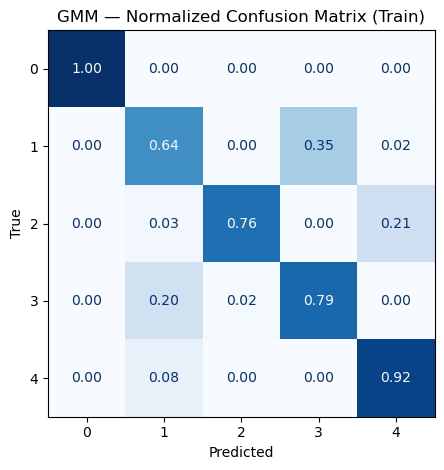

In [43]:
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, cohen_kappa_score, ConfusionMatrixDisplay

# Individual metric scorers
accuracy_scorer = cluster_metric_scorer(accuracy_score)
f1_macro_scorer = cluster_metric_scorer(lambda yt, yp: f1_score(yt, yp, average="macro"))
kappa_scorer    = cluster_metric_scorer(cohen_kappa_score)

# ----- Pipeline -----
pipe_gmm = Pipeline([
    ("scaler", StandardScaler()),
    ("gmm", GaussianMixture(random_state=42))
])

# ----- Hyperparameters -----
param_grid_gmm = {
    "gmm__n_components": [5],                 # fix to known k; or try a small range
    "gmm__covariance_type": ["full", "diag"], # try 'diag' for speed/stability
    "gmm__n_init": [5, 10, 20],                    # multiple restarts of EM
    "gmm__max_iter": [200, 300, 400, 500],
    "gmm__reg_covar": [1e-6, 1e-5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ----- GridSearch -----
gs_gmm = GridSearchCV(
    estimator=pipe_gmm,
    param_grid=param_grid_gmm,
    scoring={
        "accuracy": accuracy_scorer,
        "f1":       f1_macro_scorer,
        "kappa":    kappa_scorer,
    },
    refit="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

# ----- Fit -----
gs_gmm.fit(X_train_gmm_best, y_train_num)

# ----- Summary -----
best_idx = gs_gmm.best_index_
cvres = gs_gmm.cv_results_

print("Best params:", gs_gmm.best_params_)
print(f"Best CV Accuracy: {cvres['mean_test_accuracy'][best_idx]:.4f} ± {cvres['std_test_accuracy'][best_idx]:.4f}")
print(f"Best CV F1:       {cvres['mean_test_f1'][best_idx]:.4f} ± {cvres['std_test_f1'][best_idx]:.4f}")
print(f"Best CV Kappa:    {cvres['mean_test_kappa'][best_idx]:.4f} ± {cvres['std_test_kappa'][best_idx]:.4f}")

best_gmm = gs_gmm.best_estimator_

# ---------- Train CM ----------
y_pred_tr = best_gmm.predict(X_train_gmm_best)
y_pred_tr_aligned = hungarian_alignment(y_train_num, y_pred_tr)

ConfusionMatrixDisplay.from_predictions(
    y_train_num, y_pred_tr_aligned,
    normalize="true", cmap="Blues", values_format=".2f", colorbar=False
)
plt.title("GMM — Normalized Confusion Matrix (Train)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


# Test-set Evaluation & Comparison

This section evaluates **all trained models** on the **test set** and produces:

- Normalized confusion matrix for each model
- A comparison table with **Accuracy**, **Cohen's Kappa**, and **F1-macro**
- For **KNN, K-Means, Fuzzy C-Means, and GMM**: PCA plots showing *true labels* vs *predicted labels* with misclassifications highlighted

In [44]:
# --- Helpers + reset ---
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

F1_AVERAGE = 'macro'

def score_and_plot_cm(name, y_true, y_pred):
    # Try to use global LabelEncoder if available
    le_obj = globals().get("le", None)

    y_true_h, y_pred_h = _coerce_same_type(y_true, y_pred, le=le_obj)

    acc = accuracy_score(y_true_h, y_pred_h)
    kap = cohen_kappa_score(y_true_h, y_pred_h)
    f1  = f1_score(y_true_h, y_pred_h, average=F1_AVERAGE)

    print(f"\n{name} — Test Metrics:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Kappa:    {kap:.4f}")
    print(f"  F1({F1_AVERAGE}): {f1:.4f}")

    # Normalized CM
    cm_norm = confusion_matrix(y_true_h, y_pred_h, normalize="true")
    ConfusionMatrixDisplay(cm_norm).plot(values_format=".2f", cmap="Blues", colorbar=False)
    plt.title(f"{name} — Confusion Matrix (normalized)")
    plt.show()

    return acc, kap, f1

def _coerce_same_type(y_true, y_pred, le=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if le is not None:
        try:
            true_is_int = y_true.dtype.kind in "iu"
            pred_is_int = y_pred.dtype.kind in "iu"
            if true_is_int and pred_is_int:
                return y_true, y_pred
            elif true_is_int and not pred_is_int:
                return y_true, le.transform(y_pred)
            elif not true_is_int and pred_is_int:
                return le.transform(y_true), y_pred
            else:
                return le.transform(y_true), le.transform(y_pred)
        except Exception:
            pass
    # fallback: compare as strings
    return pd.Series(y_true).astype(str).to_numpy(), pd.Series(y_pred).astype(str).to_numpy()

def _encode_for_colors(arr, le=None):
    arr = np.asarray(arr)
    if arr.dtype.kind in "iu":
        return arr
    # Try LabelEncoder if available and compatible
    if le is not None:
        try:
            return le.transform(arr)
        except Exception:
            pass
    # Fallback: categorical codes
    return pd.Categorical(arr).codes

def pca_true_vs_pred(X, y_true, y_pred, title_prefix):
    le_obj = globals().get("le", None)

    # Make sure equality and confusion use same type
    y_true_h, y_pred_h = _coerce_same_type(y_true, y_pred, le=le_obj)

    # Encode for colors (integers)
    c_true = _encode_for_colors(y_true_h, le=le_obj)
    c_pred = _encode_for_colors(y_pred_h, le=le_obj)

    # Misclassified mask on harmonized arrays
    mis = (y_true_h != y_pred_h)
    n_mis = mis.sum()
    pct_mis = n_mis / len(y_true_h) * 100

    print(f"🔴 Misclassified points: {n_mis} ({pct_mis:.2f}%)")

    X_arr = np.asarray(X)
    X_scaled = StandardScaler().fit_transform(X_arr)
    X2 = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

    fig = plt.figure(figsize=(10, 4))

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(X2[:, 0], X2[:, 1], c=c_true, s=18, alpha=0.85)
    ax1.set_title(f"{title_prefix} — True Labels")
    ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.scatter(X2[:, 0], X2[:, 1], c=c_pred, s=18, alpha=0.85)
    ax2.scatter(X2[mis, 0], X2[mis, 1], marker="x", color="red", s=30)
    ax2.set_title(f"{title_prefix} — Predicted (x = misclassified)")
    ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")

    plt.tight_layout()
    plt.show()

def ensure_int_labels(arr):
    arr = np.asarray(arr)
    if arr.dtype.kind in 'iu':
        return arr
    try:
        return pd.Categorical(arr).codes
    except Exception:
        return arr
    
# Reset the collector for the summary table
results_rows = []

# y_test variable
try:
    y_t = ensure_int_labels(y_test)
except NameError as e:
    raise RuntimeError('y_test not found — please run your split cells first.') from e


Logistic Regression — Test Metrics:
  Accuracy: 0.9000
  Kappa:    0.8750
  F1(macro): 0.9011


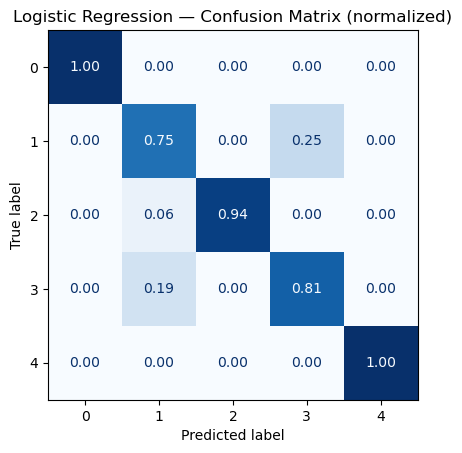

In [45]:
# === Supervised models on test ===
# --- Logistic Regression (set X_t to the correct DF for LR) ---
# Example: X_t = X_test_lr  # <-- CHANGE to your LR test dataframe
X_t = X_test_lr  # <-- CHANGE ME to the LR test feature subset
model = best_logreg  # assumes you saved the best LR as best_logreg
y_pred = model.predict(X_t)
acc, kap, f1 = score_and_plot_cm('Logistic Regression', y_t, y_pred)
results_rows.append({'Model':'Logistic Regression','Accuracy':acc,'Kappa':kap,'F1 (macro)':f1})



Decision Tree — Test Metrics:
  Accuracy: 0.9000
  Kappa:    0.8750
  F1(macro): 0.8997


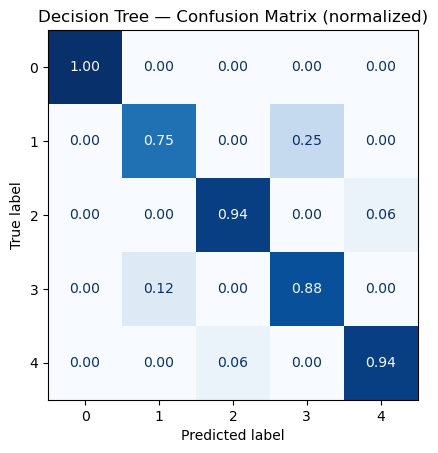

In [46]:
# --- Decision Tree (set X_t to the correct DF for DT) ---
X_t = X_test_dt 
model = best_dt  # assumes best decision tree saved as best_dt
y_pred = model.predict(X_t)
acc, kap, f1 = score_and_plot_cm('Decision Tree', y_t, y_pred)
results_rows.append({'Model':'Decision Tree','Accuracy':acc,'Kappa':kap,'F1 (macro)':f1})


Naive Bayes — Test Metrics:
  Accuracy: 0.9000
  Kappa:    0.8750
  F1(macro): 0.8992


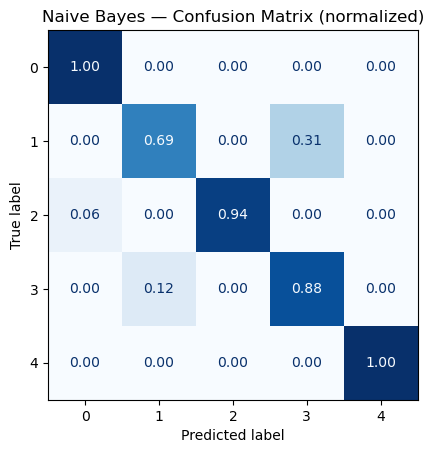

In [47]:
# --- Naive Bayes (set X_t to the correct DF for NB) ---
X_t = X_test_nb
model = best_gnb  # assumes best NB saved as best_gnb
y_pred = model.predict(X_t)
acc, kap, f1 = score_and_plot_cm('Naive Bayes', y_t, y_pred)
results_rows.append({'Model':'Naive Bayes','Accuracy':acc,'Kappa':kap,'F1 (macro)':f1})


K-Nearest Neighbors — Test Metrics:
  Accuracy: 0.9500
  Kappa:    0.9375
  F1(macro): 0.9500


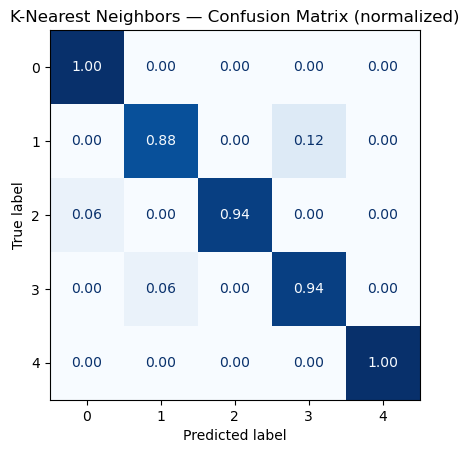

🔴 Misclassified points: 4 (5.00%)


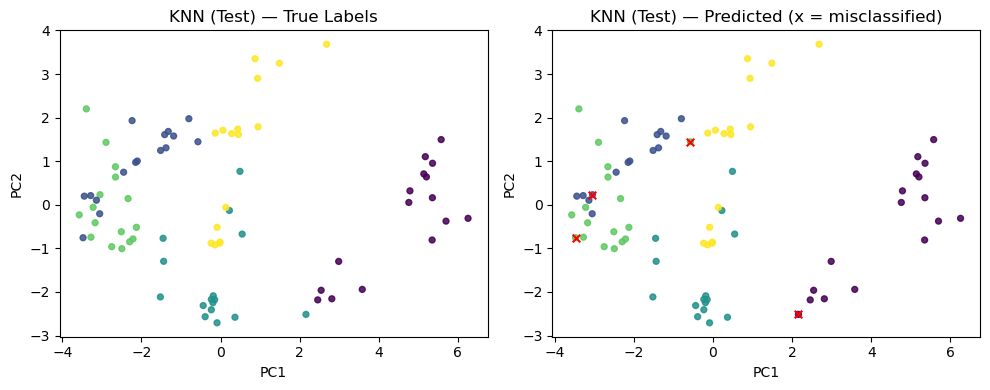

In [48]:
# --- K-Nearest Neighbors (set X_t to the correct DF for KNN) ---
X_t = X_test_knn
model = best_knn  # assumes best KNN saved as best_knn
y_pred = model.predict(X_t)
acc, kap, f1 = score_and_plot_cm('K-Nearest Neighbors', y_t, y_pred)
results_rows.append({'Model':'KNN','Accuracy':acc,'Kappa':kap,'F1 (macro)':f1})
pca_true_vs_pred(X_t, y_t, y_pred, 'KNN (Test)')


K-Means (Test) — Test Metrics:
  Accuracy: 0.6375
  Kappa:    0.5469
  F1(macro): 0.5355


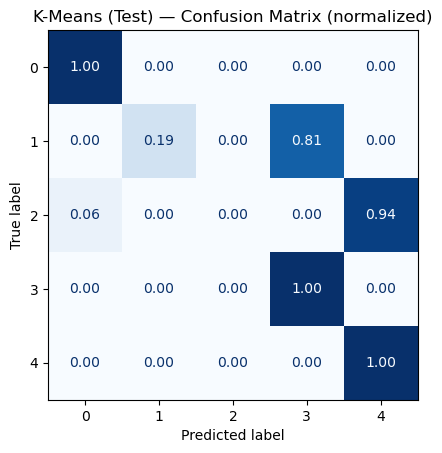

🔴 Misclassified points: 29 (36.25%)


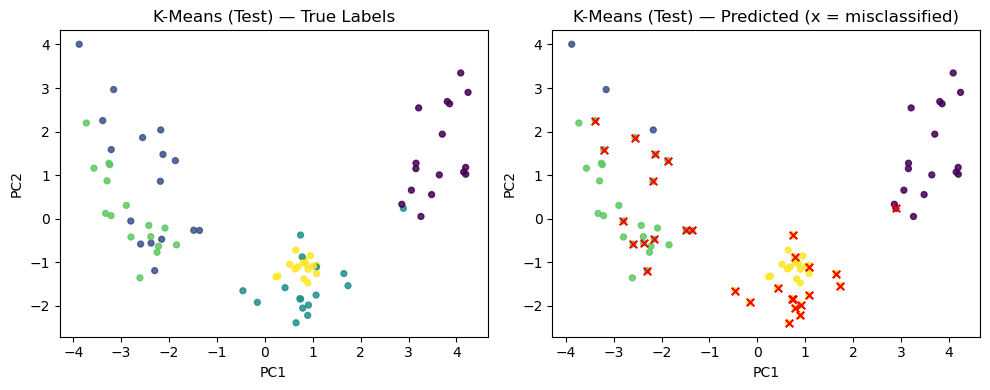

In [49]:
# --- K-Means
X_t = X_test_km_best
km = best_kmeans  # final KMeans
y_pred_raw = km.predict(X_t)
y_pred = hungarian_alignment(y_t, y_pred_raw)
acc, kap, f1 = score_and_plot_cm('K-Means (Test)', y_t, y_pred)
results_rows.append({'Model':'K-Means','Accuracy':acc,'Kappa':kap,'F1 (macro)':f1})
pca_true_vs_pred(X_t, y_t, y_pred, 'K-Means (Test)')


Fuzzy C-Means — Test Metrics:
  Accuracy: 0.8750
  Kappa:    0.8438
  F1(macro): 0.8718


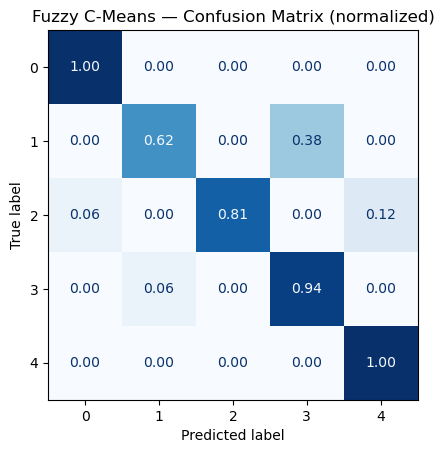

🔴 Misclassified points: 10 (12.50%)


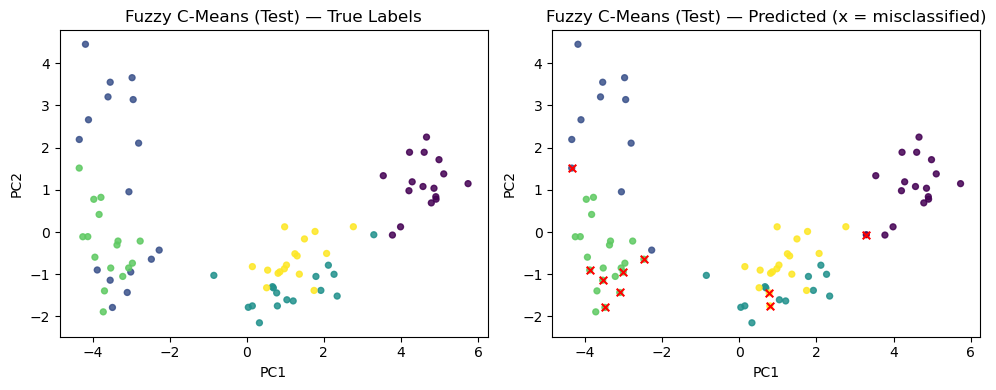

In [50]:
# --- Fuzzy C-Means
X_t = X_test_fcm_best 

scaler = best_fcm.named_steps["scaler"]
fcm_est = best_fcm.named_steps["fcm"]
cntr_final = fcm_est.centers_    # (c, d) centers in *scaled* space
m_final = fcm_est.m_
# ---- Scale X_t the same way as training
X_t_scaled = scaler.transform(X_t.to_numpy())
U = _fcm_memberships_from_centers(X_t_scaled, cntr_final, m=m_final)
y_pred_raw = U.argmax(axis=0)
y_pred = hungarian_alignment(y_t, y_pred_raw)
acc, kap, f1 = score_and_plot_cm('Fuzzy C-Means', y_t, y_pred)
results_rows.append({'Model':'Fuzzy C-Means','Accuracy':acc,'Kappa':kap,'F1 (macro)':f1})
pca_true_vs_pred(X_t_scaled, y_t, y_pred, 'Fuzzy C-Means (Test)')



Gaussian Mixture (GMM) — Test Metrics:
  Accuracy: 0.8875
  Kappa:    0.8594
  F1(macro): 0.8842


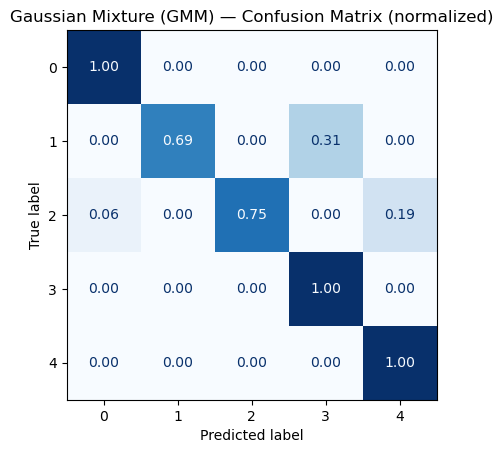

🔴 Misclassified points: 9 (11.25%)


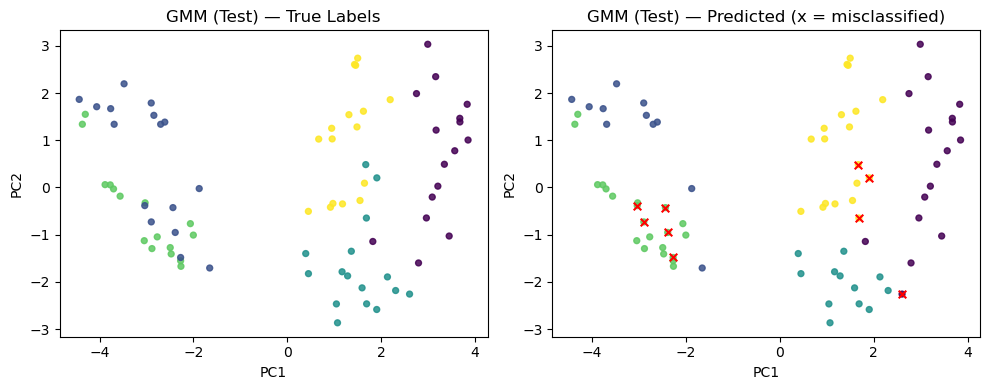

In [51]:
# --- Gaussian Mixture Models
X_t = X_test_gmm_best
gmm = best_gmm
y_pred_raw = gmm.predict(np.asarray(X_t))
y_pred = hungarian_alignment(y_t, y_pred_raw)
acc, kap, f1 = score_and_plot_cm('Gaussian Mixture (GMM)', y_t, y_pred)
results_rows.append({'Model':'GMM','Accuracy':acc,'Kappa':kap,'F1 (macro)':f1})
pca_true_vs_pred(X_t, y_t, y_pred, 'GMM (Test)')


In [52]:
# --- Summary table (built from results_rows) ---
summary_df = pd.DataFrame(results_rows)
if not summary_df.empty:
    summary_df = summary_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    display(summary_df)
else:
    print('No results collected yet. Run the per-model cells above first.')


,Model,Accuracy,Kappa,F1 (macro)
0,KNN,0.9500,0.937500,0.949951
1,Decision Tree,0.9000,0.875000,0.899706
2,Logistic Regression,0.9000,0.875000,0.901124
3,Naive Bayes,0.9000,0.875000,0.899212
4,GMM,0.8875,0.859375,0.884161
5,Fuzzy C-Means,0.8750,0.843750,0.871795
6,K-Means,0.6375,0.546875,0.535490
